# Module 6.A - NYC 311 Clustering

**Applying unsupervised clustering methods to structured service-request data**

This notebook gives you hands-on practice with the core ideas from **Module 6.A**:

- **k-means clustering**
- **hierarchical clustering**
- **DBSCAN**
- **unsupervised interpretation and stability**

You will apply multiple clustering methods to the **same NYC 311 feature table** built earlier in the course.

Because this is an **unsupervised** workflow, there is no target variable used for training the algorithms.  
Instead, you will:

- preprocess the feature table carefully
- cluster the training split
- compare behavior across algorithms
- inspect cluster size, separation, and stability
- interpret clusters using NYC 311 domain variables

---

## Why this notebook matters
In supervised learning, you can ask whether predictions match the ground truth.  
In clustering, you usually do **not** get that luxury.

So professional clustering work depends on good habits:

- use a stable preprocessing pipeline
- compare multiple clustering assumptions
- inspect whether solutions are brittle or robust
- interpret clusters in domain terms, not just with abstract metrics

This notebook follows the same disciplined workflow style you used in earlier modules, but now for **unsupervised structure discovery**.

In [1]:
# === Setup ===
import os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

warnings.filterwarnings("ignore")
SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams["figure.figsize"] = (7, 4)
print("Ready. SEED=", SEED)

Ready. SEED= 42


## 6A.1 - Load artifacts from 5.C

As in Module 5.E, we first try to load the cleaned NYC 311 table from the **Module 5 artifacts directory**.

Because your earlier load reported:

- `Loaded source: m5_artifact_clean_v2`

we try the **v2** parquet first, then fall back to the original cleaned artifact, and finally to the older Module 3 parquet if needed.

In [2]:
# === Paths ===
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")

clean_v2_path = ARTIFACT_DIR / "nyc311_features_clean_v2.parquet"
clean_path = ARTIFACT_DIR / "nyc311_features_clean.parquet"
config_v2_path = ARTIFACT_DIR / "feature_config_v2.json"
config_path = ARTIFACT_DIR / "feature_config.json"

def load_df():
    if clean_v2_path.exists():
        return pd.read_parquet(clean_v2_path), "m5_artifact_clean_v2"
    if clean_path.exists():
        return pd.read_parquet(clean_path), "m5_artifact_clean"
    if fallback_m3.exists():
        return pd.read_parquet(fallback_m3), "m3_fallback_norm"
    raise FileNotFoundError(
        f"Could not find parquet at {clean_v2_path}, {clean_path}, or {fallback_m3}"
    )

df, source_name = load_df()
print("Loaded source:", source_name)
print("Shape:", df.shape)
display(df.head(3))


Loaded source: m5_artifact_clean_v2
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,...,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,(missing),other,1,...,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,...,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,...,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


In [3]:
# Load feature config if available
config = None
if config_v2_path.exists():
    config = json.loads(config_v2_path.read_text())
    print("Loaded config:", config_v2_path.name)
elif config_path.exists():
    config = json.loads(config_path.read_text())
    print("Loaded config:", config_path.name)
else:
    print("No feature_config json found in", ARTIFACT_DIR)


Loaded config: feature_config.json


## 6A.2 - Build a preprocessing function

We keep the same preprocessing pattern used in Module 5 so that clustering does not get derailed by dtype issues or missing values:

- numeric / bool columns → median impute + standardize
- categoricals → most frequent impute + one-hot encode
- datetime columns → dropped by default

This gives us a clean, repeatable representation with no surprise NaNs.

In [4]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

## 6A.3 - Define a clustering-safe feature set

For clustering, we want a feature set that describes the requests without directly leaking outcomes or using identifiers.

So we drop:

- identifiers such as `unique_key`
- raw timestamps such as `created_date` and `created_day`
- direct outcome columns such as `status`, `is_closed`, and `resolution_hours`
- source bookkeeping like `_source`

We keep useful structured descriptors such as agency, borough, complaint type, creation-time features, and aggregate workload features.

In [5]:
DEFAULT_ID_COLS = ["unique_key", "_source"]
DEFAULT_TIME_COLS = ["created_date", "created_day"]
DEFAULT_OUTCOME = ["status", "is_closed", "resolution_hours"]

safe_drop = set()
if config is not None:
    safe_drop |= set(config.get("safe_drop", []))
else:
    safe_drop |= set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS + DEFAULT_OUTCOME)

# Explicit clustering-safe exclusions
safe_drop |= set(["unique_key", "_source", "created_date", "created_day", "status", "is_closed", "resolution_hours"])

def build_X(df_in, drop_cols):
    cols = [c for c in df_in.columns if c not in drop_cols]
    return df_in[cols].copy(), cols

X_safe, safe_cols = build_X(df, safe_drop)
print("SAFE feature count:", len(safe_cols))
print(sorted(safe_cols))

SAFE feature count: 13
['agency', 'borough_norm', 'complaint_topk', 'created_dow', 'created_hour', 'dayofweek', 'is_weekend', 'kw_noise', 'kw_rodent', 'kw_water', 'n_requests', 'street_number', 'zip_missing']


## 6A.4 - Split Randomly

As in Module 5.E, we use a **random** train / validation / test split.

Why random instead of temporal here?

- this notebook is about **algorithm behavior in clustering**, not forecasting
- the available snapshot spans only a short time window
- we want comparable partitions for interpretation and stability checks

Because clustering has no target label, we split the rows directly rather than stratifying on `y`.

In [6]:
def split_random_df(df_in, seed=SEED, train=0.70, val=0.15, test=0.15):
    assert abs(train + val + test - 1.0) < 1e-9
    train_df, tmp_df = train_test_split(df_in, test_size=(1-train), random_state=seed, shuffle=True)
    val_frac_of_tmp = val / (val + test)
    val_df, test_df = train_test_split(tmp_df, test_size=(1-val_frac_of_tmp), random_state=seed, shuffle=True)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, val_df, test_df = split_random_df(df)
print("train / val / test:", train_df.shape, val_df.shape, test_df.shape)

Xtr = train_df[safe_cols].copy()
Xva = val_df[safe_cols].copy()
Xte = test_df[safe_cols].copy()

pre = build_preprocessor(Xtr)
Xtr_pre = pre.fit_transform(Xtr)
Xva_pre = pre.transform(Xva)
Xte_pre = pre.transform(Xte)

print("Preprocessed shapes:")
print("  train:", Xtr_pre.shape)
print("  val:  ", Xva_pre.shape)
print("  test: ", Xte_pre.shape)

train / val / test: (34999, 25) (7500, 25) (7501, 25)
Preprocessed shapes:
  train: (34999, 47)
  val:   (7500, 47)
  test:  (7501, 47)


## 6A.5 - Shared helpers for clustering

We will use a few reusable helpers throughout the notebook:

- a compact function to summarize cluster sizes
- a feature-reduction helper for dense algorithms
- a simple cluster profiling helper for interpretation
- a small evaluation helper for silhouette and stability

Reminder: in unsupervised learning, no single metric is enough.  
We will combine:

- geometry-based metrics
- cluster-size sanity checks
- stability checks across seeds or samples
- domain interpretation


In [7]:
def to_dense_if_needed(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

# Dense, lower-dimensional representation for algorithms that dislike very high-dimensional sparse data
svd = TruncatedSVD(n_components=12, random_state=SEED)
Xtr_red = svd.fit_transform(Xtr_pre)
Xva_red = svd.transform(Xva_pre)
Xte_red = svd.transform(Xte_pre)
print("Reduced dense shapes:", Xtr_red.shape, Xva_red.shape, Xte_red.shape)
print("Explained variance by 12 SVD components:", round(float(svd.explained_variance_ratio_.sum()), 4))

def cluster_size_table(labels):
    s = pd.Series(labels, name="cluster")
    out = s.value_counts(dropna=False).sort_index().rename_axis("cluster").reset_index(name="n")
    out["pct"] = out["n"] / out["n"].sum()
    return out

def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    valid = labels != -1
    unique = np.unique(labels[valid])
    if len(unique) < 2:
        return np.nan
    if valid.sum() < 10:
        return np.nan
    return float(silhouette_score(X[valid], labels[valid]))

def profile_clusters(df_part, labels, cat_cols=("agency", "borough_norm", "complaint_topk"),
                     num_cols=("created_hour", "dayofweek", "n_requests", "closed_rate", "median_resolution_hours", "agency_n_requests")):
    tmp = df_part.copy()
    tmp["cluster"] = labels

    rows = []
    for cl, g in tmp.groupby("cluster"):
        row = {"cluster": cl, "n": len(g)}
        for c in cat_cols:
            if c in g.columns:
                row[f"top_{c}"] = g[c].mode(dropna=True).iloc[0] if g[c].notna().any() else np.nan
        for c in num_cols:
            if c in g.columns:
                row[f"mean_{c}"] = float(g[c].mean())
        rows.append(row)
    return pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)

def compare_labels(a, b, name_a="A", name_b="B"):
    ari = adjusted_rand_score(a, b)
    print(f"Adjusted Rand Index between {name_a} and {name_b}: {ari:.4f}")
    return ari

Reduced dense shapes: (34999, 12) (7500, 12) (7501, 12)
Explained variance by 12 SVD components: 0.9117


# PART I - k-means clustering

We start with **k-means**, the centroid-based baseline.

Because k-means expects a numeric feature space and behaves best with scaled inputs, it is a natural first algorithm after our preprocessing pipeline.

## 6A.6 - Choose a candidate k with an elbow-style scan

There is no perfect automatic choice of `k`, but two useful diagnostics are:

- **inertia**: total within-cluster squared distance
- **silhouette**: how separated clusters are relative to within-cluster tightness

We scan a small range and use both as heuristics.



,k,inertia,silhouette
0,2,329208.675555,0.274638
1,3,294551.311268,0.284458
2,4,262799.404129,0.320576
3,5,227962.475049,0.336179
4,6,209315.418547,0.221996
5,7,175897.995908,0.247377
6,8,155706.240416,0.265113


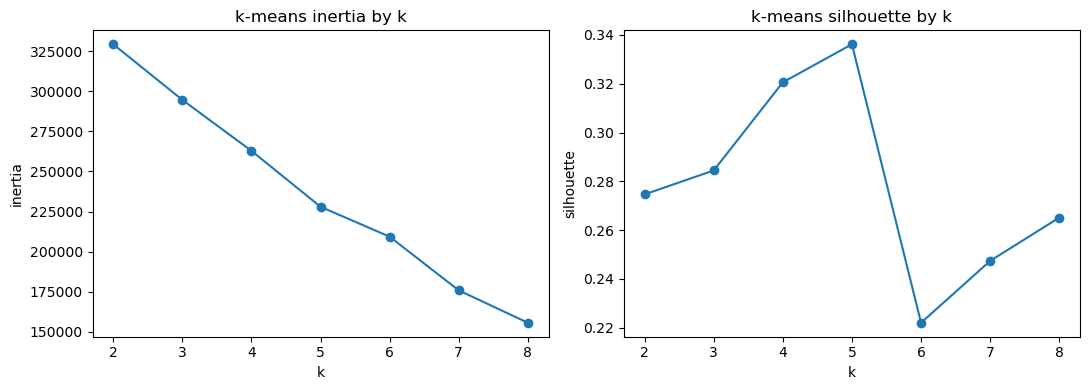

In [8]:
k_grid = list(range(2, 9))
rows = []
for k in k_grid:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(Xtr_pre)
    rows.append({
        "k": k,
        "inertia": float(km.inertia_),
        "silhouette": safe_silhouette(to_dense_if_needed(Xtr_red), labels),
    })

k_scan = pd.DataFrame(rows)
display(k_scan)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_scan["k"], k_scan["inertia"], marker="o")
ax[0].set_title("k-means inertia by k")
ax[0].set_xlabel("k")
ax[0].set_ylabel("inertia")

ax[1].plot(k_scan["k"], k_scan["silhouette"], marker="o")
ax[1].set_title("k-means silhouette by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()


,k,inertia,silhouette
0,9,140253.986425,0.276770
1,10,132748.915371,0.243272
2,11,125618.022445,0.244093
3,12,118895.301603,0.257748
4,13,114463.488962,0.258549
5,14,111125.348650,0.269022


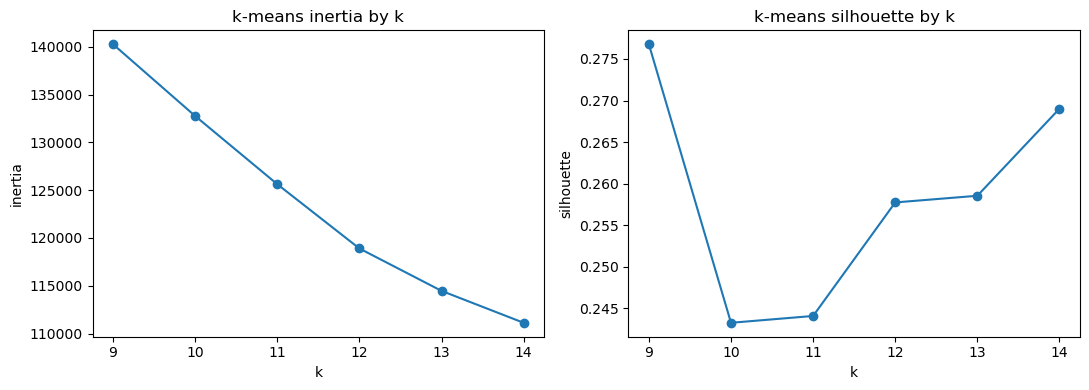

In [9]:
# If you see no clear inertia elbow and generally increasing silhouette score, try more values of k

k_grid = list(range(9, 15))
rows = []
for k in k_grid:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(Xtr_pre)
    rows.append({
        "k": k,
        "inertia": float(km.inertia_),
        "silhouette": safe_silhouette(to_dense_if_needed(Xtr_red), labels),
    })

k_scan = pd.DataFrame(rows)
display(k_scan)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_scan["k"], k_scan["inertia"], marker="o")
ax[0].set_title("k-means inertia by k")
ax[0].set_xlabel("k")
ax[0].set_ylabel("inertia")

ax[1].plot(k_scan["k"], k_scan["silhouette"], marker="o")
ax[1].set_title("k-means silhouette by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

## 6A.7 - Fit a working k-means solution and interpret it

We pick a working value of `k` from the scan above.  
You can change `K_BEST` and rerun this section if your elbow / silhouette judgment differs.


In [10]:
K_BEST = 5
km = KMeans(n_clusters=K_BEST, n_init=30, random_state=SEED)
km_tr = km.fit_predict(Xtr_pre)
km_va = km.predict(Xva_pre)
km_te = km.predict(Xte_pre)

print("Train cluster sizes:")
display(cluster_size_table(km_tr))
print("Train silhouette:", round(safe_silhouette(Xtr_red, km_tr), 4))

profile_km = profile_clusters(train_df, km_tr)
display(profile_km)

Train cluster sizes:


,cluster,n,pct
0,0,10035,0.286722
1,1,22358,0.638818
2,2,246,0.007029
3,3,933,0.026658
4,4,1427,0.040773


Train silhouette: 0.3362


,cluster,n,top_agency,top_borough_norm,top_complaint_topk,mean_created_hour,mean_dayofweek,mean_n_requests,mean_closed_rate,mean_median_resolution_hours,mean_agency_n_requests
0,0,10035,HPD,BROOKLYN,heat/hot water,12.773991,3.019432,14986.559043,0.319491,1.309961,13567.005082
1,1,22358,HPD,BROOKLYN,snow or ice,13.502192,1.494186,17224.581716,0.404324,3.251290,13526.208337
2,2,246,DOT,QUEENS,other,12.280488,1.995935,16341.983740,0.377247,2.623918,5281.219512
3,3,933,HPD,QUEENS,water system,13.055734,1.948553,16627.960343,0.377274,2.676272,10414.126474
4,4,1427,NYPD,BRONX,noise - residential,15.129643,1.861247,16695.699369,0.378634,2.816178,9940.470217


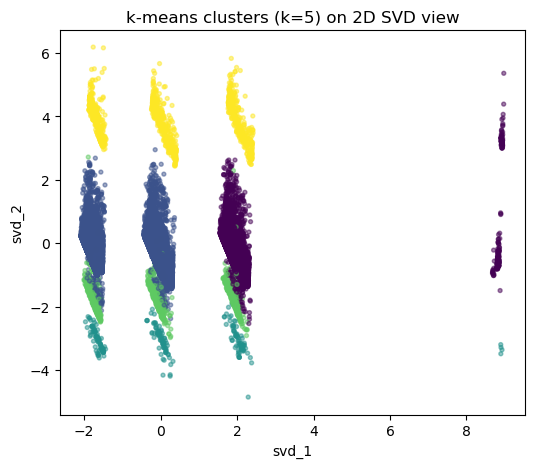

In [11]:
# Visualize clusters in a 2D SVD projection
plot_svd = TruncatedSVD(n_components=2, random_state=SEED)
Xtr_2d = plot_svd.fit_transform(Xtr_pre)

plt.figure(figsize=(6, 5))
plt.scatter(Xtr_2d[:, 0], Xtr_2d[:, 1], c=km_tr, s=8, alpha=0.5)
plt.title(f"k-means clusters (k={K_BEST}) on 2D SVD view")
plt.xlabel("svd_1")
plt.ylabel("svd_2")
plt.show()

## 6A.8 - Stability check for k-means across random seeds


Because k-means depends on initialization, a good habit is to ask:

> Do I recover roughly the same partition if I rerun with different seeds?


In [12]:
seed_list = [0, 1, 2, 3, 4]
label_bank = {}
for s in seed_list:
    model = KMeans(n_clusters=K_BEST, n_init=30, random_state=s)
    label_bank[s] = model.fit_predict(Xtr_pre)

aris = []
for i in range(len(seed_list) - 1):
    a, b = seed_list[i], seed_list[i+1]
    aris.append(compare_labels(label_bank[a], label_bank[b], f"seed {a}", f"seed {b}"))

print("Mean adjacent-seed ARI:", round(float(np.mean(aris)), 4))

Adjusted Rand Index between seed 0 and seed 1: 0.4910
Adjusted Rand Index between seed 1 and seed 2: 0.5350
Adjusted Rand Index between seed 2 and seed 3: 0.8554
Adjusted Rand Index between seed 3 and seed 4: 0.8554
Mean adjacent-seed ARI: 0.6842


# Part II - Hierarchical Clustering


Hierarchical clustering gives a **tree of merges** rather than only one partition.

On large datasets it can be expensive, so we use a manageable random subsample from the training split.

## 6A.9 - Build a dendrogram on a subsample

We use the reduced dense representation for the dendrogram so that the computation stays tractable.

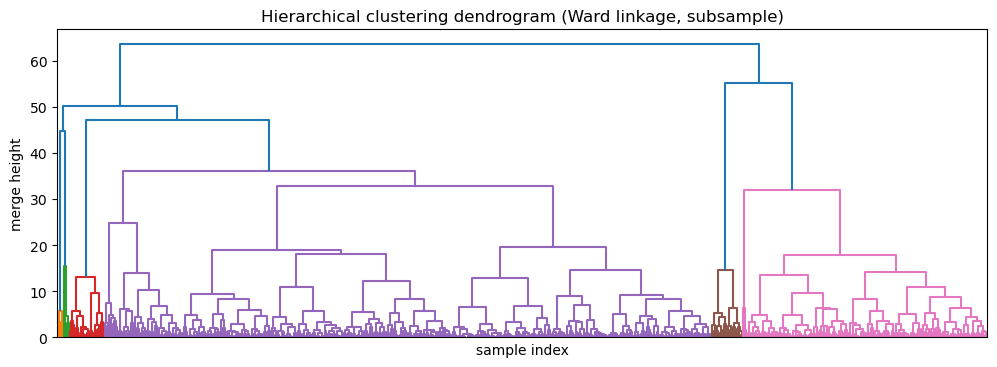

In [13]:
H_SAMPLE = 1200
h_idx = rng.choice(len(Xtr_red), size=min(H_SAMPLE, len(Xtr_red)), replace=False)
Xh = Xtr_red[h_idx]
df_h = train_df.iloc[h_idx].reset_index(drop=True)

Z = linkage(Xh, method="ward")
plt.figure(figsize=(12, 4))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical clustering dendrogram (Ward linkage, subsample)")
plt.xlabel("sample index")
plt.ylabel("merge height")
plt.show()


## 6A.10 - Cut the dendrogram and inspect the resulting clusters

We can either cut by height or ask directly for a chosen number of clusters.  
Below we do both: first by number of clusters for a clean comparison with k-means, then by height if you want to experiment.

Hierarchical cluster sizes:


,cluster,n,pct
0,0,828,0.690000
1,1,16,0.013333
2,2,41,0.034167
3,3,315,0.262500


Hierarchical silhouette: 0.2877


,cluster,n,top_agency,top_borough_norm,top_complaint_topk,mean_created_hour,mean_dayofweek,mean_n_requests,mean_closed_rate,mean_median_resolution_hours,mean_agency_n_requests
0,0,828,HPD,BROOKLYN,snow or ice,13.678744,1.520531,17180.047101,0.401942,3.224183,13364.944444
1,1,16,DOB,QUEENS,other,14.375000,2.062500,16556.062500,0.376850,2.483316,7232.312500
2,2,41,HPD,MANHATTAN,plumbing,12.268293,2.170732,16285.902439,0.359930,2.426660,10596.682927
3,3,315,HPD,BROOKLYN,heat/hot water,12.161905,3.015873,15039.936508,0.319069,1.312970,13471.961905


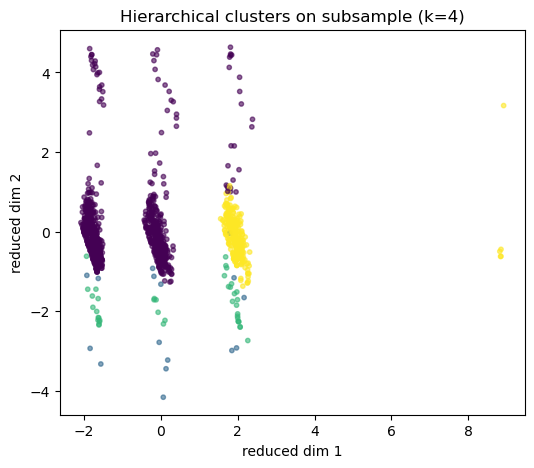

In [14]:
H_K = 4
hier = AgglomerativeClustering(n_clusters=H_K, linkage="ward")
h_labels = hier.fit_predict(Xh)

print("Hierarchical cluster sizes:")
display(cluster_size_table(h_labels))
print("Hierarchical silhouette:", round(safe_silhouette(Xh, h_labels), 4))

display(profile_clusters(df_h, h_labels))

Xh_2d = Xh[:, :2]
plt.figure(figsize=(6, 5))
plt.scatter(Xh_2d[:, 0], Xh_2d[:, 1], c=h_labels, s=10, alpha=0.6)
plt.title(f"Hierarchical clusters on subsample (k={H_K})")
plt.xlabel("reduced dim 1")
plt.ylabel("reduced dim 2")
plt.show()


In [15]:
# Optional: cut the dendrogram by height instead of by k
CUT_HEIGHT = np.percentile(Z[:, 2], 75)
cut_labels = fcluster(Z, t=CUT_HEIGHT, criterion="distance")
print("Cut height:", round(float(CUT_HEIGHT), 3))
print("Clusters from cut:", len(np.unique(cut_labels)))
display(cluster_size_table(cut_labels))

Cut height: 1.208
Clusters from cut: 301


,cluster,n,pct
0,1,1,0.000833
1,2,1,0.000833
2,3,1,0.000833
3,4,1,0.000833
4,5,1,0.000833
...,...,...,...
296,297,6,0.005000
297,298,7,0.005833
298,299,6,0.005000
299,300,2,0.001667


# Part III - DBSCAN

DBSCAN defines clusters as **connected dense regions** and can leave isolated points as noise.

Because DBSCAN is sensitive to scale and neighborhood radius, we run it on the reduced dense representation and compare several `eps` values.


## 6A.11 - Pick a reasonable neighborhood scale with k-distance intuition

A practical heuristic is to inspect the distance to each point's `min_samples`-th nearest neighbor.
A visible bend in this curve often suggests a useful `eps` range.


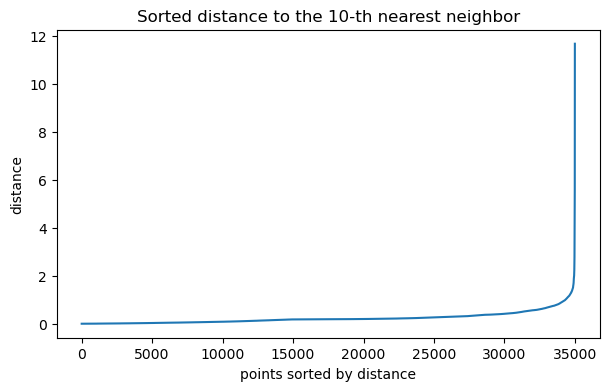

quantile 0.80: 0.3468
quantile 0.90: 0.5214
quantile 0.95: 0.7086
quantile 0.98: 0.9836


In [16]:
MIN_SAMPLES = 10
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Xtr_red)
dists, _ = nbrs.kneighbors(Xtr_red)
kdist = np.sort(dists[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(kdist)
plt.title(f"Sorted distance to the {MIN_SAMPLES}-th nearest neighbor")
plt.xlabel("points sorted by distance")
plt.ylabel("distance")
plt.show()

for q in [0.80, 0.90, 0.95, 0.98]:
    print(f"quantile {q:.2f}:", round(float(np.quantile(kdist, q)), 4))

## 6A.12 - Compare DBSCAN across muptiple eps settings


Unlike k-means, DBSCAN does not require choosing `k`, but it does require choosing what counts as a dense neighborhood.
So we evaluate several plausible `eps` values.


In [17]:
eps_grid = [0.8, 1.0, 1.2, 1.5]
db_rows = []
db_label_bank = {}

for eps in eps_grid:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(Xtr_red)
    db_label_bank[eps] = labels

    n_clusters = len(set(labels) - {-1})
    n_noise = int(np.sum(labels == -1))
    sil = safe_silhouette(Xtr_red, labels)
    db_rows.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_rate": n_noise / len(labels),
        "silhouette_non_noise": sil,
    })

dbscan_scan = pd.DataFrame(db_rows)
display(dbscan_scan)


,eps,clusters,noise_points,noise_rate,silhouette_non_noise
0,0.8,44,698,0.019943,0.132260
1,1.0,24,263,0.007515,0.244920
2,1.2,17,130,0.003714,0.248793
3,1.5,17,63,0.001800,0.248060


DBSCAN cluster sizes (-1 means noise):


,cluster,n,pct
0,-1,130,0.003714
1,0,11206,0.320181
2,1,10957,0.313066
3,2,9744,0.278408
4,3,374,0.010686
5,4,297,0.008486
6,5,285,0.008143
7,6,330,0.009429
8,7,90,0.002572
9,8,129,0.003686


DBSCAN silhouette (excluding noise): 0.2488


,cluster,n,top_agency,top_borough_norm,top_complaint_topk,mean_created_hour,mean_dayofweek,mean_n_requests,mean_closed_rate,mean_median_resolution_hours,mean_agency_n_requests
0,-1,130,HPD,BROOKLYN,other,11.200000,2.215385,14744.615385,0.385703,2.358174,10252.192308
1,0,11206,DSNY,BROOKLYN,snow or ice,13.974746,1.000000,17529.000000,0.405557,4.092778,13570.670444
2,1,10957,HPD,BROOKLYN,heat/hot water,13.023182,2.000000,16913.000000,0.403063,2.390000,13577.901342
3,2,9744,HPD,BROOKLYN,heat/hot water,13.027709,3.000000,15278.000000,0.317188,1.326389,13686.420874
4,3,374,NYPD,BROOKLYN,noise - residential,12.705882,2.000000,16913.000000,0.403063,2.390000,9945.558824
5,4,297,HPD,QUEENS,plumbing,12.757576,2.000000,16913.000000,0.403063,2.390000,10220.053872
6,5,285,HPD,QUEENS,water system,12.673684,3.000000,15278.000000,0.317188,1.326389,10364.042105
7,6,330,HPD,BROOKLYN,plumbing,13.703030,1.000000,17529.000000,0.405557,4.092778,10952.960606
8,7,90,DOHMH,MANHATTAN,other,13.777778,1.000000,17529.000000,0.405557,4.092778,6951.711111
9,8,129,NYPD,QUEENS,illegal parking,0.387597,4.000000,280.000000,0.435714,0.480972,10358.728682


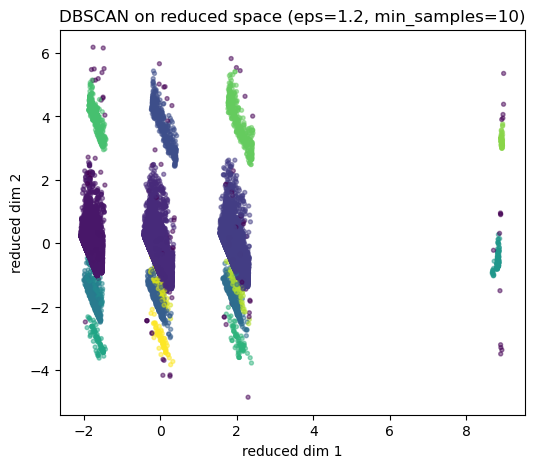

In [18]:
EPS_BEST = 1.2
db = DBSCAN(eps=EPS_BEST, min_samples=MIN_SAMPLES)
db_tr = db.fit_predict(Xtr_red)

print("DBSCAN cluster sizes (-1 means noise):")
display(cluster_size_table(db_tr))
print("DBSCAN silhouette (excluding noise):", round(safe_silhouette(Xtr_red, db_tr), 4))

display(profile_clusters(train_df, db_tr))

plt.figure(figsize=(6, 5))
plt.scatter(Xtr_red[:, 0], Xtr_red[:, 1], c=db_tr, s=8, alpha=0.5)
plt.title(f"DBSCAN on reduced space (eps={EPS_BEST}, min_samples={MIN_SAMPLES})")
plt.xlabel("reduced dim 1")
plt.ylabel("reduced dim 2")
plt.show()

# Part IV - Compare clustering behavior

Now we compare the three approaches side by side:

- **k-means:** partitions everything into `k` clusters around centroids
- **hierarchical:** gives a merge tree, then a chosen cut
- **DBSCAN:** finds dense connected regions and may leave noise unassigned

In [19]:
summary_rows = [
    {
        "method": f"k-means (k={K_BEST})",
        "n_clusters": len(np.unique(km_tr)),
        "noise_rate": 0.0,
        "silhouette": safe_silhouette(Xtr_red, km_tr),
        "largest_cluster_pct": cluster_size_table(km_tr)["pct"].max(),
    },
    {
        "method": f"hierarchical (k={H_K})",
        "n_clusters": len(np.unique(h_labels)),
        "noise_rate": 0.0,
        "silhouette": safe_silhouette(Xh, h_labels),
        "largest_cluster_pct": cluster_size_table(h_labels)["pct"].max(),
    },
    {
        "method": f"DBSCAN (eps={EPS_BEST})",
        "n_clusters": len(set(db_tr) - {-1}),
        "noise_rate": float(np.mean(db_tr == -1)),
        "silhouette": safe_silhouette(Xtr_red, db_tr),
        "largest_cluster_pct": cluster_size_table(db_tr[db_tr != -1])["pct"].max() if np.any(db_tr != -1) else np.nan,
    },
]

comparison = pd.DataFrame(summary_rows)
display(comparison)

,method,n_clusters,noise_rate,silhouette,largest_cluster_pct
0,k-means (k=5),5,0.000000,0.336179,0.638818
1,hierarchical (k=4),4,0.000000,0.287660,0.690000
2,DBSCAN (eps=1.2),17,0.003714,0.248793,0.321374


## 6A.14 - Compare qualitative profiles

The most important unsupervised question is often:

> Do the clusters correspond to meaningful differences in the domain?

Below we compare cluster profiles produced by the three algorithms.

In [20]:
print("k-means profiles")
display(profile_clusters(train_df, km_tr))

print("hierarchical profiles (subsample)")
display(profile_clusters(df_h, h_labels))

print("DBSCAN profiles")
display(profile_clusters(train_df, db_tr))


k-means profiles


,cluster,n,top_agency,top_borough_norm,top_complaint_topk,mean_created_hour,mean_dayofweek,mean_n_requests,mean_closed_rate,mean_median_resolution_hours,mean_agency_n_requests
0,0,10035,HPD,BROOKLYN,heat/hot water,12.773991,3.019432,14986.559043,0.319491,1.309961,13567.005082
1,1,22358,HPD,BROOKLYN,snow or ice,13.502192,1.494186,17224.581716,0.404324,3.251290,13526.208337
2,2,246,DOT,QUEENS,other,12.280488,1.995935,16341.983740,0.377247,2.623918,5281.219512
3,3,933,HPD,QUEENS,water system,13.055734,1.948553,16627.960343,0.377274,2.676272,10414.126474
4,4,1427,NYPD,BRONX,noise - residential,15.129643,1.861247,16695.699369,0.378634,2.816178,9940.470217


hierarchical profiles (subsample)


,cluster,n,top_agency,top_borough_norm,top_complaint_topk,mean_created_hour,mean_dayofweek,mean_n_requests,mean_closed_rate,mean_median_resolution_hours,mean_agency_n_requests
0,0,828,HPD,BROOKLYN,snow or ice,13.678744,1.520531,17180.047101,0.401942,3.224183,13364.944444
1,1,16,DOB,QUEENS,other,14.375000,2.062500,16556.062500,0.376850,2.483316,7232.312500
2,2,41,HPD,MANHATTAN,plumbing,12.268293,2.170732,16285.902439,0.359930,2.426660,10596.682927
3,3,315,HPD,BROOKLYN,heat/hot water,12.161905,3.015873,15039.936508,0.319069,1.312970,13471.961905


DBSCAN profiles


,cluster,n,top_agency,top_borough_norm,top_complaint_topk,mean_created_hour,mean_dayofweek,mean_n_requests,mean_closed_rate,mean_median_resolution_hours,mean_agency_n_requests
0,-1,130,HPD,BROOKLYN,other,11.200000,2.215385,14744.615385,0.385703,2.358174,10252.192308
1,0,11206,DSNY,BROOKLYN,snow or ice,13.974746,1.000000,17529.000000,0.405557,4.092778,13570.670444
2,1,10957,HPD,BROOKLYN,heat/hot water,13.023182,2.000000,16913.000000,0.403063,2.390000,13577.901342
3,2,9744,HPD,BROOKLYN,heat/hot water,13.027709,3.000000,15278.000000,0.317188,1.326389,13686.420874
4,3,374,NYPD,BROOKLYN,noise - residential,12.705882,2.000000,16913.000000,0.403063,2.390000,9945.558824
5,4,297,HPD,QUEENS,plumbing,12.757576,2.000000,16913.000000,0.403063,2.390000,10220.053872
6,5,285,HPD,QUEENS,water system,12.673684,3.000000,15278.000000,0.317188,1.326389,10364.042105
7,6,330,HPD,BROOKLYN,plumbing,13.703030,1.000000,17529.000000,0.405557,4.092778,10952.960606
8,7,90,DOHMH,MANHATTAN,other,13.777778,1.000000,17529.000000,0.405557,4.092778,6951.711111
9,8,129,NYPD,QUEENS,illegal parking,0.387597,4.000000,280.000000,0.435714,0.480972,10358.728682


# Part V - Stability and practical interpretation

We compare two random subsamples of the training data.
For each sample we cluster independently, then compare the solutions on the overlap using Adjusted Rand Index.

In [21]:
def subsample_indices(n_rows, frac=0.70, seed=0):
    rr = np.random.default_rng(seed)
    idx = np.arange(n_rows)
    rr.shuffle(idx)
    m = int(frac * n_rows)
    return np.sort(idx[:m])

n_rows = Xtr_pre.shape[0]

idx_a = subsample_indices(n_rows, frac=0.70, seed=101)
idx_b = subsample_indices(n_rows, frac=0.70, seed=202)

km_a = KMeans(n_clusters=K_BEST, n_init=30, random_state=101).fit_predict(Xtr_pre[idx_a])
km_b = KMeans(n_clusters=K_BEST, n_init=30, random_state=202).fit_predict(Xtr_pre[idx_b])

overlap = np.intersect1d(idx_a, idx_b)

map_a = {idx: lab for idx, lab in zip(idx_a, km_a)}
map_b = {idx: lab for idx, lab in zip(idx_b, km_b)}

labels_a_overlap = np.array([map_a[i] for i in overlap])
labels_b_overlap = np.array([map_b[i] for i in overlap])

print("Overlap size:", len(overlap))
print("Subsample stability ARI (k-means on overlap):", round(adjusted_rand_score(labels_a_overlap, labels_b_overlap), 4))


Overlap size: 17075
Subsample stability ARI (k-means on overlap): 0.892


## 6A.16 - Using known metadata for interpretation only

Although clustering is unsupervised, the NYC 311 table still contains variables that help us interpret the discovered groups.

For example, after clustering, we can ask:

- are some clusters dominated by one agency?
- do some clusters correspond to certain complaint families?
- do clusters differ in median workload or typical resolution patterns?

This does **not** turn clustering into supervised learning.  
It is a domain-validation step.

In [22]:
# Example: compare closure behavior by discovered k-means cluster (interpretation only)
interpret = train_df.copy()
interpret["km_cluster"] = km_tr
summary_interp = interpret.groupby("km_cluster").agg(
    n=("unique_key", "count"),
    closed_share=("is_closed", "mean"),
    median_resolution_hours=("median_resolution_hours", "mean"),
    agency_n_requests=("agency_n_requests", "mean"),
).reset_index()

display(summary_interp)

,km_cluster,n,closed_share,median_resolution_hours,agency_n_requests
0,0,10035,0.299552,1.309961,13567.005082
1,1,22358,0.378209,3.251290,13526.208337
2,2,246,0.430894,2.623918,5281.219512
3,3,933,0.377278,2.676272,10414.126474
4,4,1427,0.899790,2.816178,9940.470217


## 6A.17 - One last question: which clustering is most useful?

There may not be a single “best” clustering.

A useful clustering for operations might be one that:

- separates complaint families clearly
- isolates edge cases or noise
- remains reasonably stable across reruns
- yields interpretable profiles that a human stakeholder can act on

That is the standard you should use here.

# Deliverable — Clustering interpretation memo

Write **6–10 bullet points** answering the following:

1. Which method gave the most interpretable structure on NYC 311: k-means, hierarchical clustering, or DBSCAN?
2. How sensitive was each method to its parameters or random seed?
3. Did any method create one giant cluster plus tiny fragments?
4. Did DBSCAN identify meaningful noise points, or mostly over-label noise?
5. Which domain patterns appeared in the cluster profiles (agency, borough, complaint family, workload)?
6. If you had to present one clustering to a city operations team, which would you choose and why?

Optional extension:
- rerun with a different feature subset and compare whether the story stays the same
- try a different dendrogram cut or a different `eps` value
- compare train and validation cluster profiles for consistency


# Module 6.B - Dimensionality Reduction

**Compressing structured data to reveal pattern, redundancy, and neighborhood structure**

This notebook applies the main ideas from **Module 6.B** to the NYC 311 feature table you built earlier.

You will work through four dimensionality-reduction families on the **same structured dataset**:

- **PCA** — linear directions of maximum variance  
- **t-SNE** — local-neighborhood visualization  
- **UMAP** — graph-based neighborhood embedding  
- **TruncatedSVD** — low-rank structure for sparse, high-dimensional data  

We will follow a workflow similar to **Module 5.E**:

1. load the cleaned table from the Module 5 artifacts
2. build a robust preprocessing function to avoid NaN / dtype surprises
3. define an unsupervised-safe feature set
4. split randomly into train / validation / test
5. fit reducers on training data and use validation / test only for interpretation

---

## Why this notebook matters

High-dimensional structured data is hard to reason about directly.

A professional workflow is not:

> throw t-SNE at a table and trust the picture.

It is:

> preprocess carefully → define what counts as safe signal → fit multiple reducers → compare what structure each one preserves → interpret the output with domain knowledge.

This notebook is deliberately comparative.  
The goal is not just to produce a plot. The goal is to decide:

- what each method is emphasizing
- what each method is hiding
- which representation is most useful for this dataset

In [23]:
# === Setup ===
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

SEED = 42
rng = np.random.default_rng(SEED)


## 6B.1 - Load artifacts from 5.C

As in Module 5.E, we first try to load the cleaned NYC 311 table from the **Module 5 artifacts** directory.

You reported that the 5.C dataset currently loads as:

- `Loaded source: m5_artifact_clean_v2`
- shape `(50000, 25)`

So this notebook tries the **v2 parquet first**, then falls back to the older Module 5 parquet, and finally to the older Module 3 parquet if needed.

In [24]:
# === Paths ===
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")

clean_v2_path = ARTIFACT_DIR / "nyc311_features_clean_v2.parquet"
clean_path = ARTIFACT_DIR / "nyc311_features_clean.parquet"
config_v2_path = ARTIFACT_DIR / "feature_config_v2.json"
config_path = ARTIFACT_DIR / "feature_config.json"

def load_df():
    if clean_v2_path.exists():
        return pd.read_parquet(clean_v2_path), "m5_artifact_clean_v2"
    if clean_path.exists():
        return pd.read_parquet(clean_path), "m5_artifact_clean"
    if fallback_m3.exists():
        return pd.read_parquet(fallback_m3), "m3_fallback_norm"
    raise FileNotFoundError(
        f"Could not find parquet at {clean_v2_path}, {clean_path}, or {fallback_m3}"
    )

df, source_name = load_df()
print("Loaded source:", source_name)
print("Shape:", df.shape)
display(df.head(3))

Loaded source: m5_artifact_clean_v2
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,(missing),other,1,1,0,0,NaN,280,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,0,0,0,911.0,280,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,1,0,0,936.0,280,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


In [25]:
# Load feature config if available
config = None
if config_v2_path.exists():
    config = json.loads(config_v2_path.read_text())
    print("Loaded config:", config_v2_path.name)
elif config_path.exists():
    config = json.loads(config_path.read_text())
    print("Loaded config:", config_path.name)
else:
    print("No feature_config json found in", ARTIFACT_DIR)


Loaded config: feature_config.json


## 6B.2 - Build preprocessing functions

We keep the same preprocessing pattern used in Module 5.E so that mixed dtypes and missing values do not derail the notebook:

- numeric / bool columns → impute + scale
- categoricals → impute + one-hot encode
- datetime columns → dropped by default

We define two variants:

1. **dense preprocessor** for PCA / t-SNE / UMAP  
2. **sparse preprocessor** for TruncatedSVD

The sparse version uses `MaxAbsScaler` for numeric columns so we can keep a sparse matrix efficiently.

In [26]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

def build_sparse_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", MaxAbsScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
        sparse_threshold=1.0,
    )
    return pre

def describe_cols(X: pd.DataFrame):
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

## 6B.3 - Define an unsupervised-safe feature set

Even though this is unsupervised learning, we still want a **clean protocol**.

We therefore drop:

- IDs
- raw time stamps used only for bookkeeping
- direct outcome revealers such as `status`, `is_closed`, and `resolution_hours`

We keep a separate **metadata view** for interpretation after the reducers are fit.
That way, the dimensionality-reduction algorithms do **not** use those variables,
but we can still color plots by borough, complaint type, or open / closed status.

In [27]:
DEFAULT_ID_COLS = ["unique_key", "_source"]
DEFAULT_TIME_COLS = ["created_date", "created_day"]
DEFAULT_OUTCOME = ["status", "is_closed", "resolution_hours"]

unsup_drop = set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS + DEFAULT_OUTCOME)

if config is not None:
    unsup_drop |= set(config.get("safe_drop", []))
    # make sure direct outcome columns are definitely excluded
    unsup_drop |= set(DEFAULT_OUTCOME)
    unsup_drop -= set(["complaint_topk"])  # keep as a legitimate feature if present

def build_X(df_in, drop_cols):
    cols = [c for c in df_in.columns if c not in drop_cols]
    return df_in[cols].copy(), cols

X_full, feature_cols = build_X(df, unsup_drop)

meta_cols = [c for c in [
    "borough_norm", "agency", "complaint_topk", "is_closed",
    "resolution_hours", "created_hour", "dayofweek", "is_weekend"
] if c in df.columns]

meta = df[meta_cols].copy()

print("Features used for unsupervised learning:", len(feature_cols))
print("Metadata columns held out for interpretation:", meta_cols)
print("\nFeature example:", feature_cols[:15])


Features used for unsupervised learning: 13
Metadata columns held out for interpretation: ['borough_norm', 'agency', 'complaint_topk', 'is_closed', 'resolution_hours', 'created_hour', 'dayofweek', 'is_weekend']

Feature example: ['created_hour', 'dayofweek', 'is_weekend', 'agency', 'borough_norm', 'complaint_topk', 'zip_missing', 'kw_noise', 'kw_rodent', 'kw_water', 'street_number', 'n_requests', 'created_dow']


## 6B.4 - Split randomly

As in Module 5.E, we use a **random split**, not a temporal split.

Why?
The extracted dataset spans only about a week, so a temporal split would be unstable and very sensitive to short-lived patterns.

Unsupervised protocol here:

- fit preprocessors and reducers on **training**
- use **validation** for comparison / tuning choices
- use **test** only for final interpretation checks

Because this is unsupervised, the split does not prevent label leakage in the usual sense.
Instead, it enforces a habit of **not fitting everything on the whole dataset and over-trusting the picture**.

In [28]:
def split_random(X, seed=SEED, train=0.70, val=0.15, test=0.15):
    assert abs(train + val + test - 1.0) < 1e-9
    idx = np.arange(len(X))

    idx_tr, idx_tmp = train_test_split(idx, test_size=(1-train), random_state=seed)
    val_frac_of_tmp = val / (val + test)
    idx_va, idx_te = train_test_split(
        idx_tmp,
        test_size=(1-val_frac_of_tmp),
        random_state=seed,
    )
    return idx_tr, idx_va, idx_te

idx_tr, idx_va, idx_te = split_random(X_full)

Xtr = X_full.iloc[idx_tr].copy()
Xva = X_full.iloc[idx_va].copy()
Xte = X_full.iloc[idx_te].copy()

meta_tr = meta.iloc[idx_tr].copy()
meta_va = meta.iloc[idx_va].copy()
meta_te = meta.iloc[idx_te].copy()

num_cols, cat_cols, dt_cols = describe_cols(Xtr)

print("Rows:", len(df))
print("Split sizes:", len(Xtr), len(Xva), len(Xte))
print("Feature types:", len(num_cols), "numeric |", len(cat_cols), "categorical |", len(dt_cols), "datetime dropped")
display(Xtr.head(3))

Rows: 50000
Split sizes: 34999 7500 7501
Feature types: 10 numeric | 3 categorical | 0 datetime dropped


,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,created_dow
40624,14,1,0,DSNY,BROOKLYN,snow or ice,0,0,0,0,2274.0,17529,1
49425,7,1,0,DSNY,QUEENS,snow or ice,0,0,0,0,179.0,17529,1
35734,19,1,0,HPD,MANHATTAN,heat/hot water,0,0,0,0,20.0,17529,1


## 6B.5 - Shared helpers

We will reuse the same plotting and interpretation helpers across PCA, t-SNE, UMAP, and TruncatedSVD.

A few design choices:

- use **training data** for fitting
- use **manageable subsets** for slow methods such as t-SNE
- color plots by metadata columns that were **not used** by the reducer
- keep interpretation grounded in domain variables like `borough_norm` and `complaint_topk`

In [29]:
def collapse_top_categories(s: pd.Series, top_n=6, other_label="other"):
    s = s.fillna("missing").astype(str)
    keep = s.value_counts().head(top_n).index
    return s.where(s.isin(keep), other_label)

def sample_rows(X_arr, meta_df, n=4000, seed=SEED):
    n = min(n, len(X_arr))
    idx = np.random.default_rng(seed).choice(len(X_arr), size=n, replace=False)
    if hasattr(X_arr, "iloc"):
        X_s = X_arr.iloc[idx].copy()
    else:
        X_s = X_arr[idx]
    return idx, X_s, meta_df.iloc[idx].copy()

def plot_embedding(emb, meta_df, color_col, title, top_n=6, annotate=False):
    c = collapse_top_categories(meta_df[color_col], top_n=top_n) if color_col in meta_df.columns else pd.Series(["unknown"] * len(meta_df))
    labels = c.astype(str).to_numpy()
    uniq = pd.Index(labels).unique()

    plt.figure(figsize=(7, 6))
    for lab in uniq:
        mask = labels == lab
        plt.scatter(emb[mask, 0], emb[mask, 1], s=12, alpha=0.7, label=lab)

    if annotate:
        pts = np.random.default_rng(SEED).choice(len(emb), size=min(60, len(emb)), replace=False)
        for i in pts:
            txt = str(labels[i])[:10]
            plt.text(emb[i, 0], emb[i, 1], txt, fontsize=7, alpha=0.75)

    plt.title(title)
    plt.xlabel("dimension 1")
    plt.ylabel("dimension 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

def top_loadings(feature_names, component, k=12):
    s = pd.Series(component, index=feature_names)
    return pd.DataFrame({
        "positive_feature": s.sort_values(ascending=False).head(k).index,
        "positive_weight": s.sort_values(ascending=False).head(k).values,
        "negative_feature": s.sort_values(ascending=True).head(k).index,
        "negative_weight": s.sort_values(ascending=True).head(k).values,
    })

def neighbor_overlap_score(X_high, X_low, k=15):
    # Compare local neighborhoods in high- and low-dimensional spaces
    n = min(len(X_high), len(X_low))
    if n < (k + 1):
        return np.nan
    nn_hi = NearestNeighbors(n_neighbors=k+1).fit(X_high)
    nn_lo = NearestNeighbors(n_neighbors=k+1).fit(X_low)

    hi_idx = nn_hi.kneighbors(return_distance=False)[:, 1:]
    lo_idx = nn_lo.kneighbors(return_distance=False)[:, 1:]

    overlaps = []
    for a, b in zip(hi_idx, lo_idx):
        overlaps.append(len(set(a).intersection(set(b))) / k)
    return float(np.mean(overlaps))

def maybe_to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

# Part 1 - PCA on dense preprocessed features

PCA is the most transparent reducer in this notebook.

It lets us answer:

- how many directions explain most of the variance?
- which original features dominate the first few components?
- does the 2D PCA view reveal useful structure in NYC 311?

Because PCA is linear, it is also a good baseline for judging the nonlinear methods later.

In [30]:
# Fit dense preprocessor on training only
pre_dense = build_preprocessor(Xtr)
Ztr = pre_dense.fit_transform(Xtr)
Zva = pre_dense.transform(Xva)
Zte = pre_dense.transform(Xte)

Ztr = maybe_to_dense(Ztr)
Zva = maybe_to_dense(Zva)
Zte = maybe_to_dense(Zte)

feature_names_dense = list(pre_dense.get_feature_names_out())

print("Dense transformed shapes:")
print("train:", Ztr.shape, "| val:", Zva.shape, "| test:", Zte.shape)
print("First 10 transformed features:", feature_names_dense[:10])

Dense transformed shapes:
train: (34999, 47) | val: (7500, 47) | test: (7501, 47)
First 10 transformed features: ['created_hour', 'dayofweek', 'is_weekend', 'zip_missing', 'kw_noise', 'kw_rodent', 'kw_water', 'street_number', 'n_requests', 'created_dow']


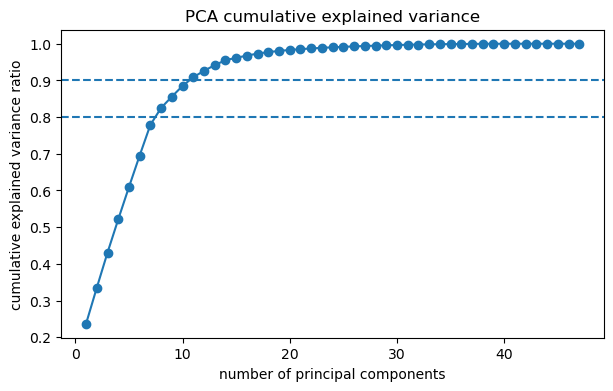

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.236909,0.236909
1,2,0.098045,0.334954
2,3,0.095720,0.430674
3,4,0.090547,0.521222
4,5,0.088107,0.609329
5,6,0.086034,0.695363
6,7,0.083547,0.778909
7,8,0.046181,0.825090
8,9,0.030660,0.855751
9,10,0.029253,0.885004


In [31]:
# Fit PCA with as many components as reasonably useful
max_pca_components = min(50, Ztr.shape[0] - 1, Ztr.shape[1])
pca_full = PCA(n_components=max_pca_components, random_state=SEED)
pca_full.fit(Ztr)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.xlabel("number of principal components")
plt.ylabel("cumulative explained variance ratio")
plt.title("PCA cumulative explained variance")
plt.show()

pca_summary = pd.DataFrame({
    "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_explained_variance": cum_var,
})
display(pca_summary.head(15))

2D PCA explained variance: [0.2369088  0.09804547] sum = 0.33495427201849926


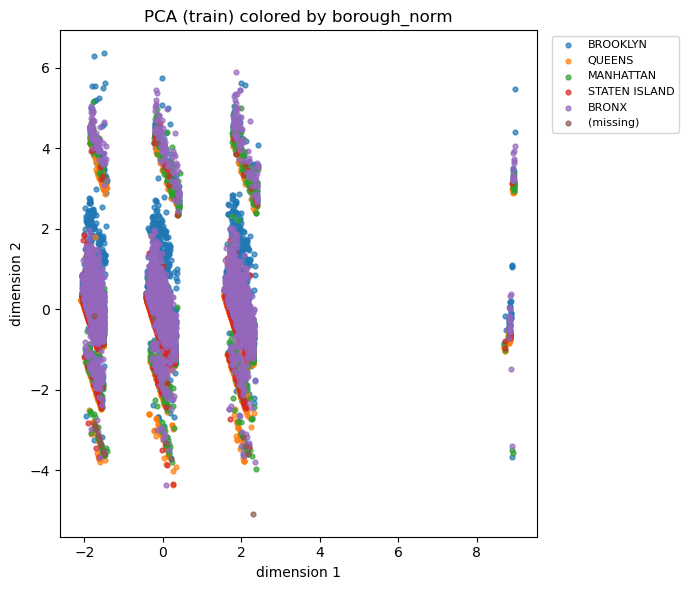

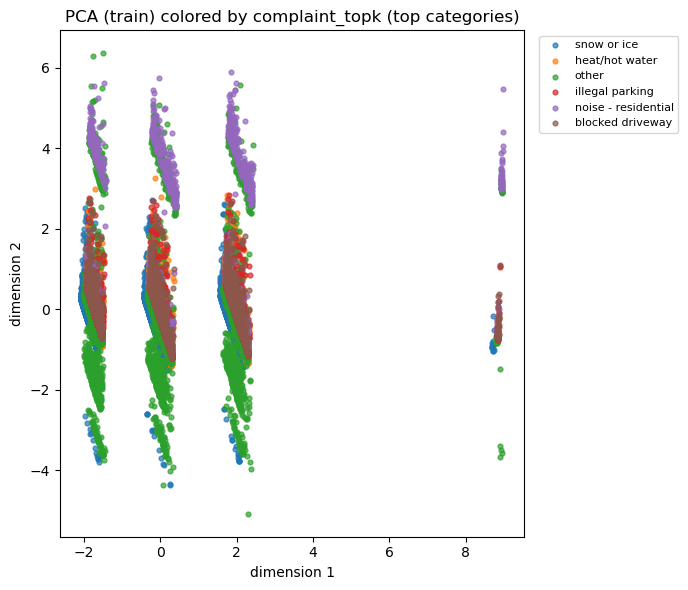

In [32]:
# 2D PCA view on train and validation
pca2 = PCA(n_components=2, random_state=SEED)
pca2_tr = pca2.fit_transform(Ztr)
pca2_va = pca2.transform(Zva)

print("2D PCA explained variance:", pca2.explained_variance_ratio_, "sum =", float(pca2.explained_variance_ratio_.sum()))

plot_embedding(
    pca2_tr,
    meta_tr,
    color_col="borough_norm",
    title="PCA (train) colored by borough_norm",
    top_n=10
)

plot_embedding(
    pca2_tr,
    meta_tr,
    color_col="complaint_topk",
    title="PCA (train) colored by complaint_topk (top categories)",
    top_n=6
)


In [33]:
# Inspect what PC1 and PC2 are "using"
pc1_table = top_loadings(feature_names_dense, pca2.components_[0], k=12)
pc2_table = top_loadings(feature_names_dense, pca2.components_[1], k=12)

print("Top loadings for PC1")
display(pc1_table)

print("Top loadings for PC2")
display(pc2_table)


Top loadings for PC1


,positive_feature,positive_weight,negative_feature,negative_weight
0,dayofweek,0.590382,n_requests,-0.526065
1,created_dow,0.590382,created_hour,-0.141066
2,agency_NYPD,0.026706,complaint_topk_snow or ice,-0.046274
3,kw_noise,0.019176,agency_DSNY,-0.045936
4,complaint_topk_heat/hot water,0.014179,borough_norm_QUEENS,-0.004946
5,agency_HPD,0.014089,borough_norm_STATEN ISLAND,-0.004758
6,complaint_topk_illegal parking,0.011699,kw_water,-0.003228
7,street_number,0.009102,complaint_topk_water leak,-0.000765
8,complaint_topk_other,0.007664,agency_DPR,-0.000744
9,borough_norm_MANHATTAN,0.006924,complaint_topk_paint/plaster,-0.000389


Top loadings for PC2


,positive_feature,positive_weight,negative_feature,negative_weight
0,kw_noise,0.733368,kw_water,-0.255499
1,created_hour,0.412033,zip_missing,-0.245158
2,street_number,0.311485,kw_rodent,-0.110672
3,agency_NYPD,0.145343,agency_DSNY,-0.073984
4,complaint_topk_noise - residential,0.104022,complaint_topk_snow or ice,-0.070293
5,borough_norm_BRONX,0.076396,borough_norm_QUEENS,-0.061580
6,borough_norm_BROOKLYN,0.022118,agency_HPD,-0.039961
7,complaint_topk_other,0.016074,n_requests,-0.038549
8,created_dow,0.009615,borough_norm_MANHATTAN,-0.018712
9,dayofweek,0.009615,borough_norm_STATEN ISLAND,-0.016855


### PCA interpretation prompt

When you look at the PCA plots, ask:

- are boroughs separating more than complaint types, or vice versa?
- are a few engineered rate features dominating the first component?
- does the 2D PCA view already show useful structure, or is most of the signal still hidden?

Remember: PCA preserves **variance**, not necessarily the neighborhoods you care about most.

# Part II - t-SNE on a manageable training subset

t-SNE is mainly a **visualization tool**.

Because it is slow and does not naturally provide a stable transform for new rows,
we fit it on a **training subset only**.

We also compress with PCA first to make the computation faster and less noisy.
This is a common practical pattern:

> preprocess → PCA to ~20 dimensions → t-SNE to 2 dimensions

In [34]:
# PCA-to-20 before t-SNE for speed / denoising
tsne_sample_n = min(4000, len(Ztr))
tsne_idx, Ztr_sample, meta_tr_sample = sample_rows(Ztr, meta_tr, n=tsne_sample_n, seed=SEED)

pca20_for_tsne = PCA(n_components=min(20, Ztr_sample.shape[1]), random_state=SEED)
Ztr_tsne_input = pca20_for_tsne.fit_transform(Ztr_sample)

print("t-SNE sample size:", len(Ztr_sample))
print("Input dims before PCA:", Ztr_sample.shape[1], "| after PCA:", Ztr_tsne_input.shape[1])

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=SEED
)

tsne_emb = tsne.fit_transform(Ztr_tsne_input)
print("t-SNE embedding shape:", tsne_emb.shape)


t-SNE sample size: 4000
Input dims before PCA: 47 | after PCA: 20
t-SNE embedding shape: (4000, 2)


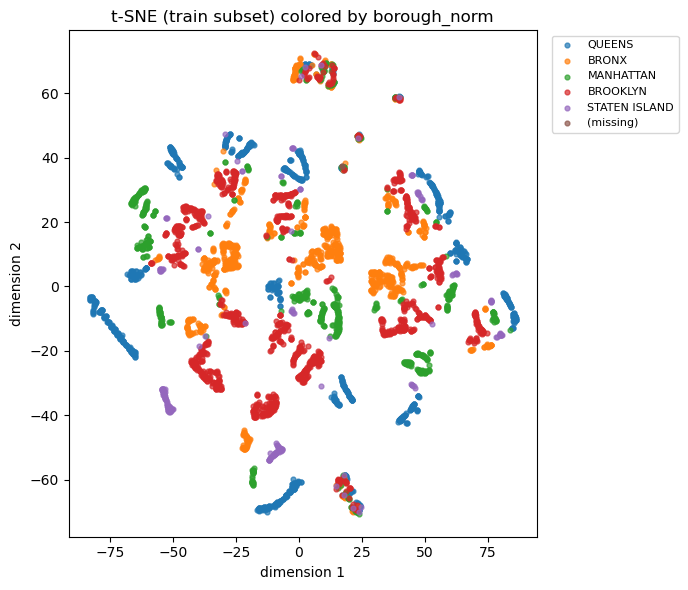

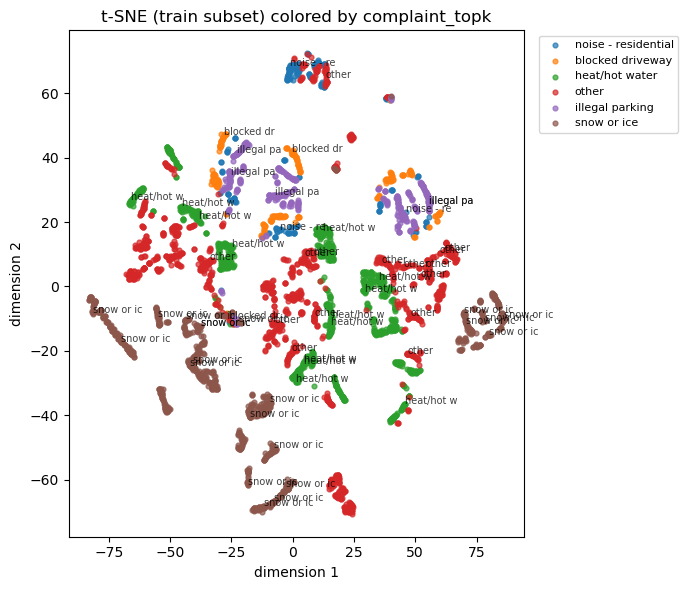

In [35]:
plot_embedding(
    tsne_emb,
    meta_tr_sample,
    color_col="borough_norm",
    title="t-SNE (train subset) colored by borough_norm",
    top_n=10
)

plot_embedding(
    tsne_emb,
    meta_tr_sample,
    color_col="complaint_topk",
    title="t-SNE (train subset) colored by complaint_topk",
    top_n=6,
    annotate=True
)


In [36]:
print("How to read the t-SNE plot:")
print("- nearby points are often locally similar")
print("- empty space between clusters should not be over-interpreted")
print("- cluster size and inter-cluster distance are not trustworthy global geometry")

tsne_trust = trustworthiness(Ztr_tsne_input, tsne_emb, n_neighbors=15)
tsne_nbr_overlap = neighbor_overlap_score(Ztr_tsne_input, tsne_emb, k=15)

print("\nt-SNE trustworthiness@15:", round(float(tsne_trust), 4))
print("t-SNE neighbor-overlap@15 :", round(float(tsne_nbr_overlap), 4))

How to read the t-SNE plot:
- nearby points are often locally similar
- empty space between clusters should not be over-interpreted
- cluster size and inter-cluster distance are not trustworthy global geometry

t-SNE trustworthiness@15: 0.9969
t-SNE neighbor-overlap@15 : 0.7715


# Part III - UMAP on the same training subset

UMAP also focuses on neighborhood structure, but it is graph-based and often preserves somewhat more global organization than t-SNE.

We will:

1. try to import `umap`
2. fit UMAP on the same training subset used for t-SNE
3. compare two neighborhood settings:
   - smaller `n_neighbors` → more local detail
   - larger `n_neighbors` → more global structure

In [37]:
try:
    import umap
    HAS_UMAP = True
    print("UMAP import successful.")
except ImportError:
    HAS_UMAP = False
    print("UMAP is not installed in this environment.")
    print("Install with: pip install umap-learn")

UMAP import successful.


In [38]:
if HAS_UMAP:
    umap_results = {}
    for n_neighbors in [15, 75]:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=0.15,
            random_state=SEED,
        )
        emb = reducer.fit_transform(Ztr_tsne_input)
        umap_results[n_neighbors] = emb

        print(f"n_neighbors={n_neighbors}")
        print("  trustworthiness@15:", round(float(trustworthiness(Ztr_tsne_input, emb, n_neighbors=15)), 4))
        print("  neighbor-overlap@15 :", round(float(neighbor_overlap_score(Ztr_tsne_input, emb, k=15)), 4))
else:
    umap_results = {}

n_neighbors=15
  trustworthiness@15: 0.9927
  neighbor-overlap@15 : 0.6766
n_neighbors=75
  trustworthiness@15: 0.9833
  neighbor-overlap@15 : 0.5783


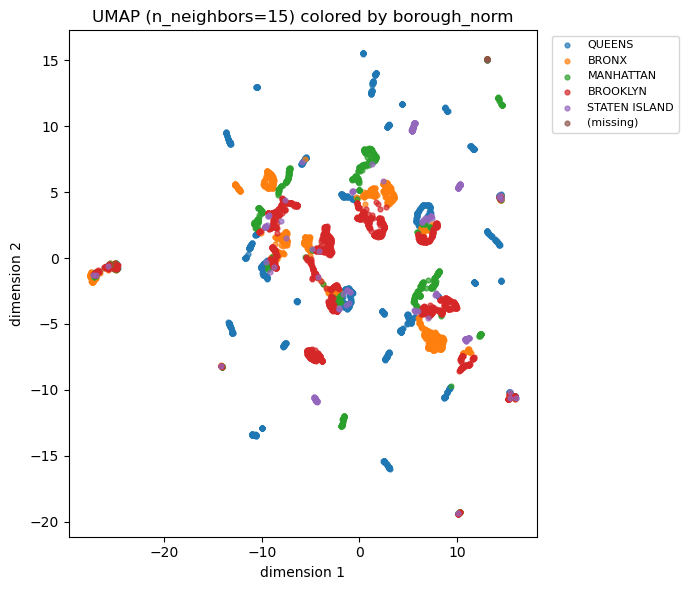

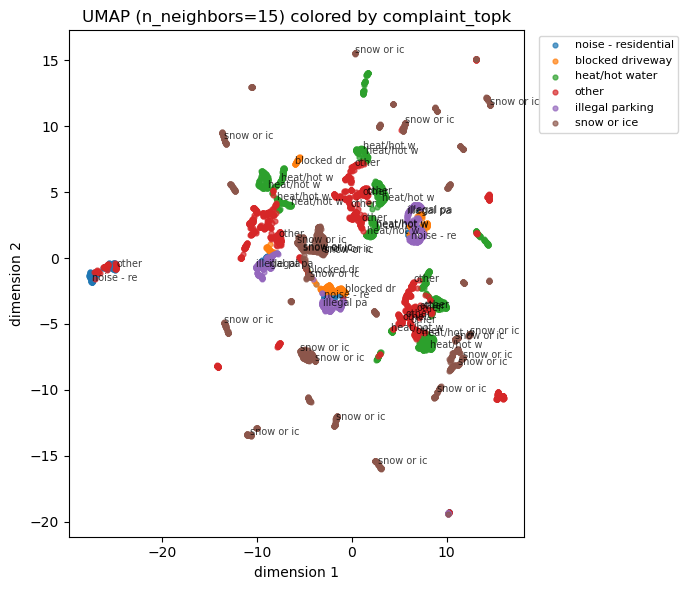

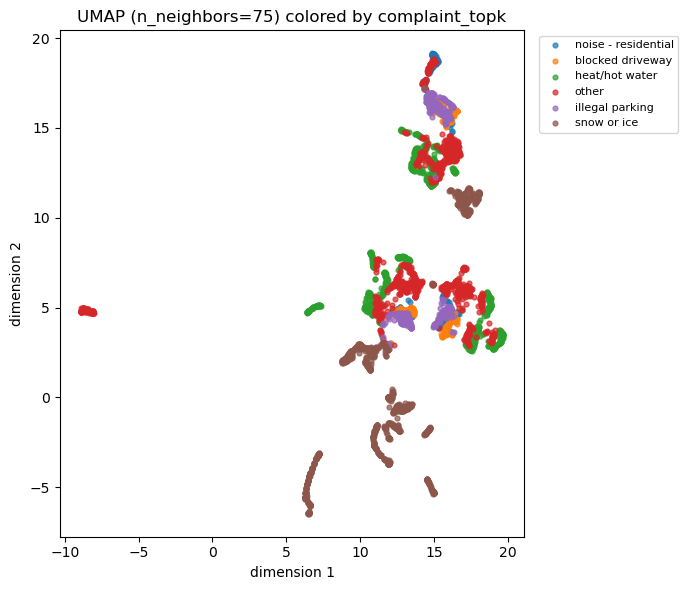

In [39]:
if HAS_UMAP:
    plot_embedding(
        umap_results[15],
        meta_tr_sample,
        color_col="borough_norm",
        title="UMAP (n_neighbors=15) colored by borough_norm",
        top_n=10
    )

    plot_embedding(
        umap_results[15],
        meta_tr_sample,
        color_col="complaint_topk",
        title="UMAP (n_neighbors=15) colored by complaint_topk",
        top_n=6,
        annotate=True
    )

    plot_embedding(
        umap_results[75],
        meta_tr_sample,
        color_col="complaint_topk",
        title="UMAP (n_neighbors=75) colored by complaint_topk",
        top_n=6
    )
else:
    print("Skipping UMAP plots because umap-learn is not installed.")

In [40]:
if HAS_UMAP:
    print("How to read the UMAP plots:")
    print("1) Each point is a 311 request represented in 2D.")
    print("2) Nearby points are requests that look similar under the feature representation.")
    print("3) Smaller n_neighbors emphasizes local detail; larger n_neighbors emphasizes broader structure.")
    print("4) The embedding is still an interpretation, not a literal map of the original data.")
else:
    print("UMAP not available. Once installed, rerun the UMAP cells above.")

How to read the UMAP plots:
1) Each point is a 311 request represented in 2D.
2) Nearby points are requests that look similar under the feature representation.
3) Smaller n_neighbors emphasizes local detail; larger n_neighbors emphasizes broader structure.
4) The embedding is still an interpretation, not a literal map of the original data.


# Part IV - TruncatedSVD on sparse mixed features

TruncatedSVD is especially useful when the transformed feature matrix is:

- high-dimensional
- sparse
- dominated by one-hot encoded categorical structure

That is exactly what often happens with structured civic-service data after one-hot encoding.

Here we build a **sparse preprocessor** in the same spirit as our dense one,
fit TruncatedSVD on the training matrix,
and inspect the reduced representation.


Sparse transformed train shape: (34999, 47)
Sparse matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Feature example: ['created_hour', 'dayofweek', 'is_weekend', 'zip_missing', 'kw_noise', 'kw_rodent', 'kw_water', 'street_number', 'n_requests', 'created_dow']


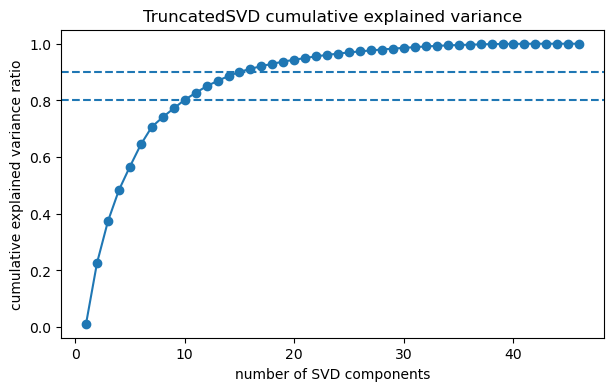

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.012193,0.012193
1,2,0.214478,0.226671
2,3,0.147429,0.374100
3,4,0.109655,0.483756
4,5,0.082709,0.566464
5,6,0.078099,0.644564
6,7,0.062207,0.706771
7,8,0.034129,0.740900
8,9,0.031071,0.771971
9,10,0.030062,0.802033


In [41]:
# Sparse preprocessing + TruncatedSVD
pre_sparse = build_sparse_preprocessor(Xtr)
S_tr = pre_sparse.fit_transform(Xtr)
S_va = pre_sparse.transform(Xva)

feature_names_sparse = list(pre_sparse.get_feature_names_out())

print("Sparse transformed train shape:", S_tr.shape)
print("Sparse matrix type:", type(S_tr))
print("Feature example:", feature_names_sparse[:10])

svd_max = min(50, S_tr.shape[0] - 1, S_tr.shape[1] - 1)
svd_full = TruncatedSVD(n_components=svd_max, random_state=SEED)
svd_full.fit(S_tr)

svd_cum_var = np.cumsum(svd_full.explained_variance_ratio_)

plt.figure()
plt.plot(np.arange(1, len(svd_cum_var) + 1), svd_cum_var, marker="o")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.xlabel("number of SVD components")
plt.ylabel("cumulative explained variance ratio")
plt.title("TruncatedSVD cumulative explained variance")
plt.show()

svd_summary = pd.DataFrame({
    "component": np.arange(1, len(svd_full.explained_variance_ratio_) + 1),
    "explained_variance_ratio": svd_full.explained_variance_ratio_,
    "cumulative_explained_variance": svd_cum_var,
})
display(svd_summary.head(15))


2D SVD explained variance: [0.01219258 0.21447826] sum = 0.2266708419194235


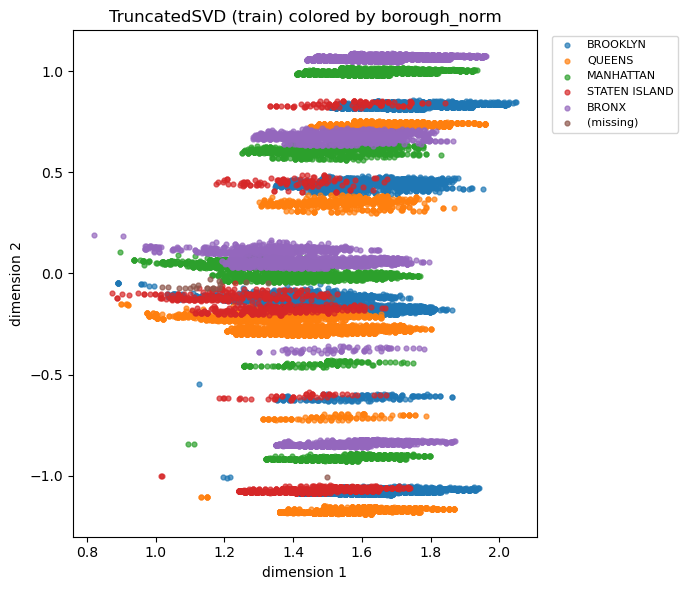

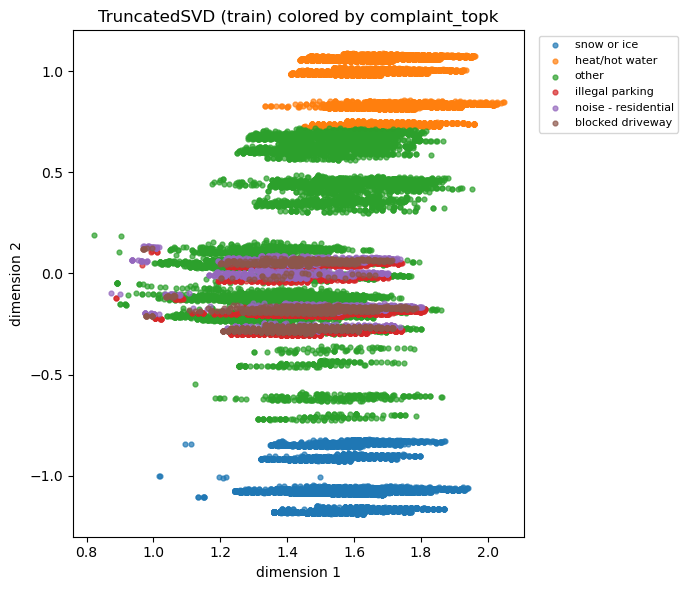

In [42]:
svd2 = TruncatedSVD(n_components=2, random_state=SEED)
svd2_tr = svd2.fit_transform(S_tr)
svd2_va = svd2.transform(S_va)

print("2D SVD explained variance:", svd2.explained_variance_ratio_, "sum =", float(svd2.explained_variance_ratio_.sum()))

plot_embedding(
    svd2_tr,
    meta_tr,
    color_col="borough_norm",
    title="TruncatedSVD (train) colored by borough_norm",
    top_n=10
)

plot_embedding(
    svd2_tr,
    meta_tr,
    color_col="complaint_topk",
    title="TruncatedSVD (train) colored by complaint_topk",
    top_n=6
)


In [43]:
svd1_table = top_loadings(feature_names_sparse, svd2.components_[0], k=12)
svd2_table = top_loadings(feature_names_sparse, svd2.components_[1], k=12)

print("Top loadings for SVD component 1")
display(svd1_table)

print("Top loadings for SVD component 2")
display(svd2_table)

Top loadings for SVD component 1


,positive_feature,positive_weight,negative_feature,negative_weight
0,n_requests,0.603642,is_weekend,-1.694066e-21
1,created_hour,0.379699,agency_OTI,2.975962e-05
2,dayofweek,0.321033,borough_norm_(missing),2.804270e-04
3,created_dow,0.321033,agency_OOS,6.083903e-04
4,agency_HPD,0.253405,agency_DCWP,1.512451e-03
5,borough_norm_BROOKLYN,0.208014,agency_EDC,1.513334e-03
6,agency_DSNY,0.170615,agency_DOE,1.692111e-03
7,complaint_topk_heat/hot water,0.167297,agency_TLC,2.823373e-03
8,complaint_topk_snow or ice,0.160743,zip_missing,3.976555e-03
9,borough_norm_QUEENS,0.149934,kw_rodent,4.426783e-03


Top loadings for SVD component 2


,positive_feature,positive_weight,negative_feature,negative_weight
0,agency_HPD,0.531813,agency_DSNY,-0.494436
1,complaint_topk_heat/hot water,0.399989,complaint_topk_snow or ice,-0.478582
2,borough_norm_BRONX,0.164993,borough_norm_QUEENS,-0.165349
3,borough_norm_MANHATTAN,0.096267,borough_norm_BROOKLYN,-0.070931
4,complaint_topk_unsanitary condition,0.025943,borough_norm_STATEN ISLAND,-0.064198
5,complaint_topk_plumbing,0.024061,agency_NYPD,-0.060475
6,dayofweek,0.017267,n_requests,-0.045448
7,created_dow,0.017267,complaint_topk_illegal parking,-0.030903
8,complaint_topk_paint/plaster,0.015903,complaint_topk_other,-0.017767
9,complaint_topk_door/window,0.015467,complaint_topk_blocked driveway,-0.017520


## TruncatedSVD interpretation prompt

Ask:

- does sparse categorical structure dominate the first few SVD directions?
- does SVD look more similar to PCA or less?
- are borough / complaint patterns becoming cleaner after the sparse factorization?

This method often becomes especially valuable when the dataset contains many one-hot categories.

# Part V - Compare methods, stability, and usefuleness

Now we bring the methods together.

A good comparison asks at least three different questions:

1. **Compression:** how much variance / structure is captured quickly?
2. **Neighborhood quality:** how well are local relationships preserved?
3. **Usefulness:** which plots actually tell a human something actionable about NYC 311?

For a quantitative hint, we compare:

- cumulative explained variance (PCA / SVD)
- trustworthiness@15
- neighbor-overlap@15

Remember:
these scores are helpful, but they do **not** replace careful visual interpretation.

In [44]:
comparison_rows = []

# PCA scores on the same sample used for t-SNE / UMAP
pca_sample_emb = pca20_for_tsne.transform(Ztr_sample)[:, :2]
comparison_rows.append({
    "method": "PCA_2D",
    "kind": "linear",
    "explained_var_2d": float(pca2.explained_variance_ratio_.sum()),
    "trustworthiness@15": float(trustworthiness(Ztr_sample, pca_sample_emb, n_neighbors=15)),
    "neighbor_overlap@15": float(neighbor_overlap_score(Ztr_sample, pca_sample_emb, k=15)),
})

comparison_rows.append({
    "method": "tSNE_2D",
    "kind": "nonlinear",
    "explained_var_2d": np.nan,
    "trustworthiness@15": float(trustworthiness(Ztr_tsne_input, tsne_emb, n_neighbors=15)),
    "neighbor_overlap@15": float(neighbor_overlap_score(Ztr_tsne_input, tsne_emb, k=15)),
})

if HAS_UMAP:
    for n_neighbors, emb in umap_results.items():
        comparison_rows.append({
            "method": f"UMAP_2D_n{n_neighbors}",
            "kind": "nonlinear",
            "explained_var_2d": np.nan,
            "trustworthiness@15": float(trustworthiness(Ztr_tsne_input, emb, n_neighbors=15)),
            "neighbor_overlap@15": float(neighbor_overlap_score(Ztr_tsne_input, emb, k=15)),
        })

comparison_rows.append({
    "method": "TruncatedSVD_2D",
    "kind": "linear_sparse",
    "explained_var_2d": float(svd2.explained_variance_ratio_.sum()),
    "trustworthiness@15": float(trustworthiness(maybe_to_dense(S_tr[:tsne_sample_n]), svd2_tr[:tsne_sample_n], n_neighbors=15)),
    "neighbor_overlap@15": float(neighbor_overlap_score(maybe_to_dense(S_tr[:tsne_sample_n]), svd2_tr[:tsne_sample_n], k=15)),
})

comparison = pd.DataFrame(comparison_rows).sort_values(["trustworthiness@15", "neighbor_overlap@15"], ascending=False)
display(comparison)


,method,kind,explained_var_2d,trustworthiness@15,neighbor_overlap@15
1,tSNE_2D,nonlinear,NaN,0.996936,0.771467
2,UMAP_2D_n15,nonlinear,NaN,0.992682,0.676583
3,UMAP_2D_n75,nonlinear,NaN,0.983335,0.578267
4,TruncatedSVD_2D,linear_sparse,0.226671,0.927214,0.337417
0,PCA_2D,linear,0.334954,0.909512,0.249083


In [45]:
# Side-by-side qualitative summary table (fill from your observations)
observation_rows = [
    {
        "method": "PCA",
        "best_for": "global variance, interpretable loadings, linear redundancy",
        "main_risk": "misses nonlinear neighborhood structure",
        "what_to_look_for_here": "whether a few dominant civic-service patterns explain much of the table"
    },
    {
        "method": "t-SNE",
        "best_for": "local neighborhood visualization",
        "main_risk": "global distances and cluster spacing are misleading",
        "what_to_look_for_here": "whether complaint categories form compact local islands"
    },
    {
        "method": "UMAP",
        "best_for": "local neighborhoods with somewhat more global organization",
        "main_risk": "parameter sensitivity and over-interpretation of layout",
        "what_to_look_for_here": "whether borough / complaint patterns remain stable across n_neighbors"
    },
    {
        "method": "TruncatedSVD",
        "best_for": "sparse one-hot-heavy feature spaces",
        "main_risk": "still linear and sometimes harder to narrate than PCA",
        "what_to_look_for_here": "whether sparse categorical structure produces a cleaner low-rank view"
    },
]
display(pd.DataFrame(observation_rows))

,method,best_for,main_risk,what_to_look_for_here
0,PCA,"global variance, interpretable loadings, linea...",misses nonlinear neighborhood structure,whether a few dominant civic-service patterns ...
1,t-SNE,local neighborhood visualization,global distances and cluster spacing are misle...,whether complaint categories form compact loca...
2,UMAP,local neighborhoods with somewhat more global ...,parameter sensitivity and over-interpretation ...,whether borough / complaint patterns remain st...
3,TruncatedSVD,sparse one-hot-heavy feature spaces,still linear and sometimes harder to narrate t...,whether sparse categorical structure produces ...


## Final professional question

If you had to hand one 2D representation of NYC 311 to a teammate for fast exploration, which would you choose?

A strong answer should combine:

- quantitative evidence
- plot interpretation
- parameter stability
- interpretability
- computational cost


## Deliverable — Dimensionality-reduction memo

Write **12 bullets** using actual values from your outputs.

1. How many PCA components were needed to explain about **80%** of the variance?  
2. How many PCA components were needed to explain about **90%** of the variance?  
3. Which original features dominated **PC1** and **PC2**?  
4. Did the 2D PCA view separate **boroughs**, **complaint types**, or neither particularly well?  
5. What did the **t-SNE** plot reveal that PCA did not?  
6. What should you **not** conclude from the t-SNE layout?  
7. If UMAP was available, how did changing `n_neighbors` alter the picture?  
8. Which reducer had the strongest **trustworthiness@15**?  
9. Which reducer gave the most useful human interpretation of NYC 311 structure?  
10. Did **TruncatedSVD** behave more like PCA or produce meaningfully different structure?  
11. Which metadata slice (borough, agency, complaint type, open / closed) looked most visually coherent in reduced space?  
12. If you were building a downstream clustering or visualization workflow, which representation would you keep and why?

# Module 6.C - Semi-Supervised Learning

NYC 311 is a labeled dataset, so in this notebook we will utilize semi-supervised learning by intentionally dropping most labels. This creates a realistic semi-supervised setting. We will: 

1. load the engineered NYC 311 dataset from Module 5.C  
2. split it randomly into train / validation / test  
3. **drop most labels only inside the training set**  
4. compare:
   - a supervised baseline trained only on the visible labels
   - **label spreading**
   - **pseudo-labeling / self-training**

We will use:

- **target:** `is_closed`
- **evaluation:** validation and test sets that keep their true labels

## Setup

In [46]:
# === Setup ===
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.semi_supervised import LabelSpreading, SelfTrainingClassifier

from pandas.api.types import (
    is_bool_dtype,
    is_datetime64_any_dtype,
    is_numeric_dtype,
)

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 200)
np.random.seed(SEED)

## 6C.2 - Load artifacts

In [47]:
# === Paths ===
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")

clean_v2_path = ARTIFACT_DIR / "nyc311_features_clean_v2.parquet"
clean_path = ARTIFACT_DIR / "nyc311_features_clean.parquet"
config_v2_path = ARTIFACT_DIR / "feature_config_v2.json"
config_path = ARTIFACT_DIR / "feature_config.json"

def load_df():
    if clean_v2_path.exists():
        return pd.read_parquet(clean_v2_path), "m5_artifact_clean_v2"
    if clean_path.exists():
        return pd.read_parquet(clean_path), "m5_artifact_clean"
    if fallback_m3.exists():
        return pd.read_parquet(fallback_m3), "m3_fallback_norm"
    raise FileNotFoundError(
        f"Could not find parquet at {clean_v2_path}, {clean_path}, or {fallback_m3}"
    )

df, source_name = load_df()
print("Loaded source:", source_name)
print("Shape:", df.shape)
display(df.head(3))


Loaded source: m5_artifact_clean_v2
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,(missing),other,1,1,0,0,NaN,280,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,0,0,0,911.0,280,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,1,0,0,936.0,280,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


In [48]:
# Load feature config if available
config = None
if config_v2_path.exists():
    config = json.loads(config_v2_path.read_text())
    print("Loaded config:", config_v2_path.name)
elif config_path.exists():
    config = json.loads(config_path.read_text())
    print("Loaded config:", config_path.name)
else:
    print("No feature_config json found in", ARTIFACT_DIR)

Loaded config: feature_config.json


## 6C.3 - Preprocessing

We keep the same preprocessing pattern used in the earlier supervised notebooks to avoid dtype and NaN surprises:

- numeric / bool columns → median impute + standardize
- categoricals → most frequent impute + one-hot encode
- datetime columns → dropped by default

This is important here because graph-based methods like `LabelSpreading` are stricter than many standard supervised models.  
If the transformed arrays contain NaN or inf values, they will fail.


In [49]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

def describe_cols(X: pd.DataFrame):
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

def sanitize_array(X):
    X = np.asarray(X, dtype=float)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def eval_probs(y_true, p, threshold=0.5, label=""):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p, dtype=float)
    yhat = (p >= threshold).astype(int)

    out = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "f1": float(f1_score(y_true, yhat, zero_division=0)),
    }

    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except Exception:
        out["roc_auc"] = float("nan")

    try:
        out["avg_precision"] = float(average_precision_score(y_true, p))
    except Exception:
        out["avg_precision"] = float("nan")

    try:
        out["brier"] = float(brier_score_loss(y_true, p))
    except Exception:
        out["brier"] = float("nan")

    try:
        out["log_loss"] = float(log_loss(y_true, p, labels=[0, 1]))
    except Exception:
        out["log_loss"] = float("nan")

    return out

## 6C.4 - Define a leakage-aware feature set

We use a **SAFE** feature set here. In particular, we drop:

- identifiers
- raw timestamps used mainly as identifiers
- direct outcome fields
- outcome-derived rate / resolution columns that would leak the target


In [50]:
DEFAULT_ID_COLS = ["unique_key", "_source"]
DEFAULT_TIME_COLS = ["created_date", "created_day"]
DEFAULT_OUTCOME = [
    "status",
    "is_closed",
    "resolution_hours",
    "closed_rate",
    "median_resolution_hours",
    "agency_closed_rate",
    "agency_median_resolution",
]

safe_drop = set()
if config is not None:
    safe_drop |= set(config.get("safe_drop", []))

safe_drop |= set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS + DEFAULT_OUTCOME)

def build_X(df_in, drop_cols):
    cols = [c for c in df_in.columns if c not in drop_cols]
    return df_in[cols].copy(), cols

X, feature_cols = build_X(df, safe_drop)

print("SAFE features:", len(feature_cols))
print("Example columns:", feature_cols[:20])


SAFE features: 13
Example columns: ['created_hour', 'dayofweek', 'is_weekend', 'agency', 'borough_norm', 'complaint_topk', 'zip_missing', 'kw_noise', 'kw_rodent', 'kw_water', 'street_number', 'n_requests', 'created_dow']


## 6C.5 - Define the task and split randomly

We use the same practical binary target from earlier notebooks:

- **Target:** `is_closed`

Because this dataset covers only a short time window, we use a **random stratified split**.

In [51]:
if "is_closed" not in df.columns:
    raise ValueError("Expected is_closed in dataframe.")

y = df["is_closed"].astype(int).to_numpy()

def split_random(X, y, stratify=None, seed=SEED, train=0.70, val=0.15, test=0.15):
    assert abs(train + val + test - 1.0) < 1e-9

    Xtr, Xtmp, ytr, ytmp = train_test_split(
        X, y, test_size=(1 - train), random_state=seed, stratify=stratify
    )

    val_frac_of_tmp = val / (val + test)
    Xva, Xte, yva, yte = train_test_split(
        Xtmp,
        ytmp,
        test_size=(1 - val_frac_of_tmp),
        random_state=seed,
        stratify=(ytmp if stratify is not None else None),
    )
    return Xtr, Xva, Xte, ytr, yva, yte

Xtr, Xva, Xte, ytr, yva, yte = split_random(X, y, stratify=y)

pre = build_preprocessor(Xtr)
num_cols, cat_cols, dt_cols = describe_cols(Xtr)

print("Rows:", len(df))
print("Split sizes:", len(ytr), len(yva), len(yte))
print("Positive rates:", float(np.mean(ytr)), float(np.mean(yva)), float(np.mean(yte)))
print("Feature types:", len(num_cols), "numeric |", len(cat_cols), "categorical |", len(dt_cols), "datetime dropped")
display(Xtr.head(3))


Rows: 50000
Split sizes: 34999 7500 7501
Positive rates: 0.3778679390839738 0.3778666666666667 0.3779496067191041
Feature types: 10 numeric | 3 categorical | 0 datetime dropped


,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,created_dow
46158,10,1,0,HPD,QUEENS,paint/plaster,0,0,0,0,40.0,17529,1
48383,8,1,0,HPD,BROOKLYN,electric,0,0,0,0,2447.0,17529,1
24542,12,2,0,HPD,BRONX,heat/hot water,0,0,0,0,295.0,16913,2


## 6C.6 - Hide most training labels to create the semi-supervised setting

This is the key step.

We **do not** drop labels from the validation or test sets.  
We only hide many labels **inside the training set**.

Why?

Because semi-supervised learning assumes:

- a small labeled subset
- a much larger unlabeled training pool

So we simulate that directly:

- keep only a small fraction of training labels visible
- mark the rest as unlabeled with `-1`

The true labels still exist in the background, which lets us evaluate how well the semi-supervised methods recover useful signal.


In [52]:
visible_label_fraction = 0.10  # keep 10% of training labels visible

ytr = np.asarray(ytr).astype(int)
yva = np.asarray(yva).astype(int)
yte = np.asarray(yte).astype(int)

# Stratified visible-label mask inside the training set
visible_idx = []
for cls in np.unique(ytr):
    cls_idx = np.where(ytr == cls)[0]
    keep_n = max(1, int(round(len(cls_idx) * visible_label_fraction)))
    chosen = rng.choice(cls_idx, size=keep_n, replace=False)
    visible_idx.extend(chosen.tolist())

visible_idx = np.array(sorted(visible_idx))
label_mask = np.zeros(len(ytr), dtype=bool)
label_mask[visible_idx] = True

# ytr_ssl is the semi-supervised version: visible labels stay 0/1, hidden ones become -1
ytr_ssl = ytr.astype(int).copy()
ytr_ssl[~label_mask] = -1

print("Training rows:", len(ytr))
print("Visible labels:", int(label_mask.sum()))
print("Hidden labels:", int((~label_mask).sum()))
print("Visible fraction:", round(float(label_mask.mean()), 4))
print("Unique values in ytr_ssl:", np.unique(ytr_ssl))

Training rows: 34999
Visible labels: 3499
Hidden labels: 31500
Visible fraction: 0.1
Unique values in ytr_ssl: [-1  0  1]


## 6C.7 - A supervised baseline trained only on the visible labels


This gives us the right baseline comparison.

A standard supervised model cannot use unlabeled rows directly, so we train it only on the visible-label subset.

In [53]:
baseline_pipe = Pipeline([
    ("pre", build_preprocessor(Xtr)),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")),
])

baseline_pipe.fit(Xtr.iloc[label_mask], ytr[label_mask])

p_va_base = baseline_pipe.predict_proba(Xva)[:, 1]
p_te_base = baseline_pipe.predict_proba(Xte)[:, 1]

baseline_val = eval_probs(yva, p_va_base, label="supervised_visible_only_val")
baseline_test = eval_probs(yte, p_te_base, label="supervised_visible_only_test")

display(pd.DataFrame([baseline_val, baseline_test]))

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,supervised_visible_only_val,0.5,0.857733,0.807732,0.818278,0.812971,0.925395,0.916975,0.097835,0.317804
1,supervised_visible_only_test,0.5,0.853086,0.795835,0.822222,0.808813,0.917588,0.910263,0.102466,0.333382


## 6C.8 - Build the numeric representation used for semi-supervised methods

Semi-supervised methods in this notebook will work on a numeric feature space. We will:

1. preprocess the train / validation / test sets  
2. reduce dimensionality with `TruncatedSVD`  
3. standardize the reduced representation  
4. explicitly sanitize the arrays to ensure there are no NaN or inf values

This is the most important stability step in the notebook.


In [54]:
ssl_pre = build_preprocessor(Xtr)

Xtr_pre = ssl_pre.fit_transform(Xtr)
Xva_pre = ssl_pre.transform(Xva)
Xte_pre = ssl_pre.transform(Xte)

if sparse.issparse(Xtr_pre):
    n_features_after_pre = Xtr_pre.shape[1]
else:
    n_features_after_pre = np.asarray(Xtr_pre).shape[1]

svd_dim = min(60, max(5, n_features_after_pre - 1))
print("Preprocessed training shape:", Xtr_pre.shape)
print("Using TruncatedSVD dimension:", svd_dim)

svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
Xtr_svd = svd.fit_transform(Xtr_pre)
Xva_svd = svd.transform(Xva_pre)
Xte_svd = svd.transform(Xte_pre)

Xtr_svd = sanitize_array(Xtr_svd)
Xva_svd = sanitize_array(Xva_svd)
Xte_svd = sanitize_array(Xte_svd)

post_scaler = StandardScaler()
Xtr_ssl_num = post_scaler.fit_transform(Xtr_svd)
Xva_ssl_num = post_scaler.transform(Xva_svd)
Xte_ssl_num = post_scaler.transform(Xte_svd)

Xtr_ssl_num = sanitize_array(Xtr_ssl_num)
Xva_ssl_num = sanitize_array(Xva_ssl_num)
Xte_ssl_num = sanitize_array(Xte_ssl_num)

print("Numeric SSL training shape:", Xtr_ssl_num.shape)
print("NaN check:", int(np.isnan(Xtr_ssl_num).sum()), int(np.isnan(Xva_ssl_num).sum()), int(np.isnan(Xte_ssl_num).sum()))


Preprocessed training shape: (34999, 47)
Using TruncatedSVD dimension: 46
Numeric SSL training shape: (34999, 46)
NaN check: 0 0 0


## 6C.9 - Quick visualization of the reduced feature space

This is not used for training directly; it is just a sanity check.

We project the numeric representation to two dimensions with PCA so we can see whether the labeled and unlabeled points appear mixed, clustered, or highly overlapping.

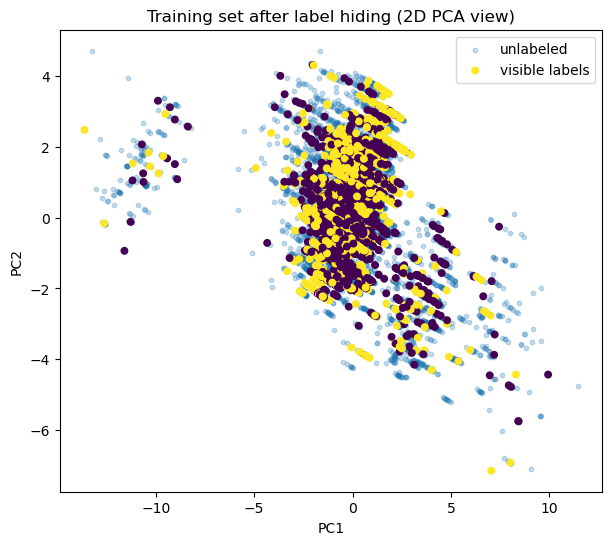

In [55]:
pca2 = PCA(n_components=2, random_state=SEED)
Xtr_2d = pca2.fit_transform(Xtr_ssl_num)

plt.figure(figsize=(7, 6))
plt.scatter(Xtr_2d[~label_mask, 0], Xtr_2d[~label_mask, 1], s=10, alpha=0.25, label="unlabeled")
plt.scatter(Xtr_2d[label_mask, 0], Xtr_2d[label_mask, 1], c=ytr[label_mask], s=22, label="visible labels")
plt.title("Training set after label hiding (2D PCA view)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## 6C.10 - Label Spreading

Label spreading is the graph-based method from the lesson.

Conceptually, it works like this:

- build a similarity graph among training points
- keep the visible labels as anchors
- let label information diffuse through the graph
- infer labels for unlabeled points

A practical note:

`LabelSpreading` can be expensive on very large datasets, so we train it on a **large subset** of the training rows rather than the entire 35k-row training set.

In [56]:
labelspread_n = min(8000, len(Xtr_ssl_num))
ls_idx = rng.choice(len(Xtr_ssl_num), size=labelspread_n, replace=False)

X_ls = sanitize_array(Xtr_ssl_num[ls_idx])
y_ls_true = np.asarray(ytr)[ls_idx].astype(int)
y_ls = np.asarray(ytr_ssl)[ls_idx].astype(int)

print("Label spreading subset size:", len(X_ls))
print("Visible labels in subset:", int(np.sum(y_ls != -1)))
print("Unlabeled rows in subset:", int(np.sum(y_ls == -1)))
print("NaNs in X_ls:", int(np.isnan(X_ls).sum()))

ls_model = LabelSpreading(kernel="knn", n_neighbors=15, alpha=0.2, max_iter=30)
ls_model.fit(X_ls, y_ls)

ls_subset_pred = ls_model.transduction_
ls_subset_acc = float((ls_subset_pred == y_ls_true).mean())
ls_unlabeled_acc = float((ls_subset_pred[y_ls == -1] == y_ls_true[y_ls == -1]).mean())

p_va_ls = ls_model.predict_proba(Xva_ssl_num)[:, 1]
p_te_ls = ls_model.predict_proba(Xte_ssl_num)[:, 1]

p_va_ls = np.nan_to_num(p_va_ls, nan=0.5, posinf=1.0, neginf=0.0)
p_te_ls = np.nan_to_num(p_te_ls, nan=0.5, posinf=1.0, neginf=0.0)

p_va_ls = np.clip(p_va_ls, 1e-6, 1 - 1e-6)
p_te_ls = np.clip(p_te_ls, 1e-6, 1 - 1e-6)

label_spreading_results = {
    "subset_accuracy": ls_subset_acc,
    "unlabeled_subset_accuracy": ls_unlabeled_acc,
    "n_subset": int(len(y_ls_true)),
    "n_labeled": int(np.sum(y_ls != -1)),
    "n_unlabeled": int(np.sum(y_ls == -1)),
}

print("Subset accuracy:", round(label_spreading_results["subset_accuracy"], 4))
print("Originally-unlabeled subset accuracy:", round(label_spreading_results["unlabeled_subset_accuracy"], 4))

display(pd.DataFrame([
    eval_probs(yva, p_va_ls, label="label_spreading_val"),
    eval_probs(yte, p_te_ls, label="label_spreading_test"),
]))


Label spreading subset size: 8000
Visible labels in subset: 810
Unlabeled rows in subset: 7190
NaNs in X_ls: 0
Subset accuracy: 0.8525
Originally-unlabeled subset accuracy: 0.8359


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,label_spreading_val,0.5,0.842800,0.821110,0.746648,0.782111,0.897101,0.871470,0.126361,0.791944
1,label_spreading_test,0.5,0.836822,0.812573,0.738624,0.773836,0.892788,0.865221,0.129897,0.817800


## 6C.11 - Pseudo-labeling / self-training

Pseudo-labeling takes a different route.

Instead of diffusing labels through a graph, it:

1. trains a classifier on the visible labels  
2. predicts the unlabeled rows  
3. keeps only sufficiently confident predictions  
4. adds them back into training  
5. repeats

Scikit-learn implements this workflow as `SelfTrainingClassifier`.

In [58]:
base_estimator = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",
)

try:
    self_training_model = SelfTrainingClassifier(
        estimator=base_estimator,
        threshold=0.85,
        max_iter=10,
        verbose=True,
    )
except TypeError:
    self_training_model = SelfTrainingClassifier(
        base_estimator=base_estimator,
        threshold=0.85,
        max_iter=10,
        verbose=True,
    )

self_training_model.fit(Xtr_ssl_num, ytr_ssl)

p_va_st = self_training_model.predict_proba(Xva_ssl_num)[:, 1]
p_te_st = self_training_model.predict_proba(Xte_ssl_num)[:, 1]

pseudo_val = eval_probs(yva, p_va_st, label="pseudo_labeling_val")
pseudo_test = eval_probs(yte, p_te_st, label="pseudo_labeling_test")

display(pd.DataFrame([pseudo_val, pseudo_test]))

End of iteration 1, added 19399 new labels.
End of iteration 2, added 4089 new labels.
End of iteration 3, added 1606 new labels.
End of iteration 4, added 919 new labels.
End of iteration 5, added 662 new labels.
End of iteration 6, added 450 new labels.
End of iteration 7, added 300 new labels.
End of iteration 8, added 242 new labels.
End of iteration 9, added 169 new labels.
End of iteration 10, added 105 new labels.


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,pseudo_labeling_val,0.5,0.855733,0.793960,0.834862,0.813897,0.921778,0.911484,0.116292,0.503683
1,pseudo_labeling_test,0.5,0.850953,0.784932,0.834215,0.808824,0.914871,0.904854,0.121047,0.539967


## 6C.12 - Compare all methods

Now we can compare:

- **Supervised baseline:** trained only on the visible labels
- **Label spreading:** graph-based diffusion on a training subset
- **Pseudo-labeling:** self-training on the full hidden-label training set

Remember the key question:

> does unlabeled data help enough to beat the visible-label-only baseline?

In [59]:
comparison = pd.DataFrame([
    baseline_val,
    baseline_test,
    eval_probs(yva, p_va_ls, label="label_spreading_val"),
    eval_probs(yte, p_te_ls, label="label_spreading_test"),
    pseudo_val,
    pseudo_test,
])

display(comparison)

print("Label spreading diagnostics:")
for k, v in label_spreading_results.items():
    print(f"  {k}: {v}")


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,supervised_visible_only_val,0.5,0.857733,0.807732,0.818278,0.812971,0.925395,0.916975,0.097835,0.317804
1,supervised_visible_only_test,0.5,0.853086,0.795835,0.822222,0.808813,0.917588,0.910263,0.102466,0.333382
2,label_spreading_val,0.5,0.842800,0.821110,0.746648,0.782111,0.897101,0.871470,0.126361,0.791944
3,label_spreading_test,0.5,0.836822,0.812573,0.738624,0.773836,0.892788,0.865221,0.129897,0.817800
4,pseudo_labeling_val,0.5,0.855733,0.793960,0.834862,0.813897,0.921778,0.911484,0.116292,0.503683
5,pseudo_labeling_test,0.5,0.850953,0.784932,0.834215,0.808824,0.914871,0.904854,0.121047,0.539967


Label spreading diagnostics:
  subset_accuracy: 0.8525
  unlabeled_subset_accuracy: 0.8358831710709318
  n_subset: 8000
  n_labeled: 810
  n_unlabeled: 7190


## 6C.13 - Threshold behavior on the test set

Probabilities are not useful only at threshold 0.5.

We inspect how the pseudo-labeling model behaves across thresholds, because in operational settings the precision / recall tradeoff may matter more than raw accuracy.

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,supervised_visible_only,0.10,0.593254,0.480851,0.956614,0.640000,0.917588,0.910263,0.102466,0.333382
1,pseudo_labeling,0.10,0.817624,0.703580,0.894180,0.787512,0.914871,0.904854,0.121047,0.539967
2,supervised_visible_only,0.15,0.692841,0.555163,0.942504,0.698745,0.917588,0.910263,0.102466,0.333382
3,pseudo_labeling,0.15,0.826023,0.717577,0.889947,0.794521,0.914871,0.904854,0.121047,0.539967
4,supervised_visible_only,0.20,0.749767,0.611292,0.928042,0.737078,0.917588,0.910263,0.102466,0.333382


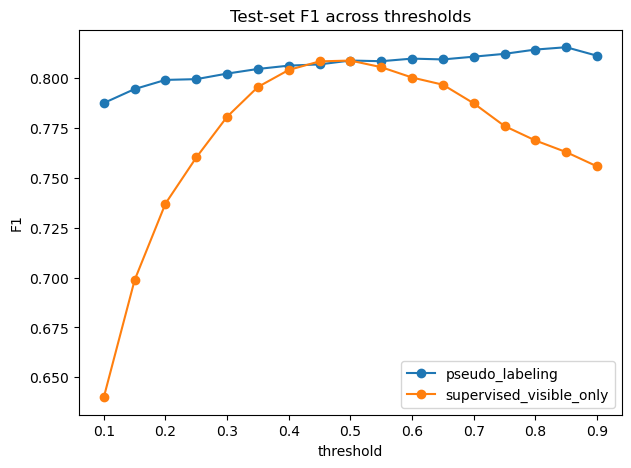

In [60]:
thresholds = np.linspace(0.1, 0.9, 17)
rows = []

for t in thresholds:
    rows.append(eval_probs(yte, p_te_base, threshold=t, label="supervised_visible_only"))
    rows.append(eval_probs(yte, p_te_st, threshold=t, label="pseudo_labeling"))

sweep = pd.DataFrame(rows)
display(sweep.head())

plt.figure(figsize=(7, 5))
for label, grp in sweep.groupby("label"):
    plt.plot(grp["threshold"], grp["f1"], marker="o", label=label)
plt.title("Test-set F1 across thresholds")
plt.xlabel("threshold")
plt.ylabel("F1")
plt.legend()
plt.show()

## 14) What happened?

Use the results above to answer:

1. Did semi-supervised learning beat the supervised visible-label-only baseline?  
2. Did **label spreading** and **pseudo-labeling** help by similar amounts?  
3. Which method seems more stable on this dataset?  
4. What might go wrong if the visible labels were noisier or less representative?  

A few interpretation reminders:

- if semi-supervised learning helps, that suggests the unlabeled data contains useful structure
- if it does not help much, the structure may not align strongly with `is_closed`
- if results are unstable, that is part of the lesson too: semi-supervised learning is powerful, but assumption-sensitive


# Module 6.D - Evaluation Challenges and Algorithm comparisions

In this notebook, you will apply the ideas from Section D to the engineered NYC 311 dataset.

You will:

- load the cleaned feature table from **Module 5.C**
- build a preprocessing pipeline in the same style as earlier notebooks
- create a random train/validation/test split
- compare several **unsupervised** methods on the same data
- evaluate them using **internal metrics**, **stability checks**, and **domain-driven summaries**
- compare those signals to a **semi-supervised** setting where only a small fraction of training labels are visible

Throughout the notebook, remember the main lesson of Section D:

**when there is no full ground truth, evaluation becomes an exercise in combining evidence rather than trusting one metric.**

## 6D.1 - Setup

In [61]:
# === Setup ===
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.semi_supervised import LabelSpreading, SelfTrainingClassifier

from pandas.api.types import (
    is_bool_dtype,
    is_datetime64_any_dtype,
    is_numeric_dtype,
)

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 200)
np.random.seed(SEED)


## 6D.2 - Load Artifacts

In [62]:
# === Paths ===
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")

clean_v2_path = ARTIFACT_DIR / "nyc311_features_clean_v2.parquet"
clean_path = ARTIFACT_DIR / "nyc311_features_clean.parquet"
config_v2_path = ARTIFACT_DIR / "feature_config_v2.json"
config_path = ARTIFACT_DIR / "feature_config.json"

def load_df():
    if clean_v2_path.exists():
        return pd.read_parquet(clean_v2_path), "m5_artifact_clean_v2"
    if clean_path.exists():
        return pd.read_parquet(clean_path), "m5_artifact_clean"
    if fallback_m3.exists():
        return pd.read_parquet(fallback_m3), "m3_fallback_norm"
    raise FileNotFoundError(
        f"Could not find parquet at {clean_v2_path}, {clean_path}, or {fallback_m3}"
    )

df, source_name = load_df()
print("Loaded source:", source_name)
print("Shape:", df.shape)
display(df.head(3))


Loaded source: m5_artifact_clean_v2
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,(missing),other,1,1,0,0,NaN,280,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,0,0,0,911.0,280,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,1,0,0,936.0,280,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


In [63]:
# Load feature config if available
config = None
if config_v2_path.exists():
    config = json.loads(config_v2_path.read_text())
    print("Loaded config:", config_v2_path.name)
elif config_path.exists():
    config = json.loads(config_path.read_text())
    print("Loaded config:", config_path.name)
else:
    print("No feature_config json found in", ARTIFACT_DIR)

Loaded config: feature_config.json


## 6D.3 - Preprocessing

In [64]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

def describe_cols(X: pd.DataFrame):
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

def sanitize_array(X):
    X = np.asarray(X, dtype=float)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def eval_probs(y_true, p, threshold=0.5, label=""):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p, dtype=float)
    p = np.clip(np.nan_to_num(p, nan=0.5, posinf=1.0, neginf=0.0), 1e-6, 1 - 1e-6)
    yhat = (p >= threshold).astype(int)

    out = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "f1": float(f1_score(y_true, yhat, zero_division=0)),
    }

    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except Exception:
        out["roc_auc"] = float("nan")

    try:
        out["avg_precision"] = float(average_precision_score(y_true, p))
    except Exception:
        out["avg_precision"] = float("nan")

    try:
        out["brier"] = float(brier_score_loss(y_true, p))
    except Exception:
        out["brier"] = float("nan")

    try:
        out["log_loss"] = float(log_loss(y_true, p, labels=[0, 1]))
    except Exception:
        out["log_loss"] = float("nan")

    return out

## 6D.4 - Define a leakage-aware feature set

As in Module 6.C, we build a **SAFE** feature set that removes obvious identifiers, timestamps, and outcome-like columns that would leak the target or trivialize the evaluation.

In [65]:
DEFAULT_ID_COLS = ["unique_key", "_source"]
DEFAULT_TIME_COLS = ["created_date", "created_day"]
DEFAULT_OUTCOME = [
    "status",
    "is_closed",
    "resolution_hours",
    "closed_rate",
    "median_resolution_hours",
    "agency_closed_rate",
    "agency_median_resolution",
]

safe_drop = set()
if config is not None:
    safe_drop |= set(config.get("safe_drop", []))

safe_drop |= set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS + DEFAULT_OUTCOME)

def build_X(df_in, drop_cols):
    cols = [c for c in df_in.columns if c not in drop_cols]
    return df_in[cols].copy(), cols

X, feature_cols = build_X(df, safe_drop)

print("SAFE features:", len(feature_cols))
print("Example columns:", feature_cols[:20])


SAFE features: 13
Example columns: ['created_hour', 'dayofweek', 'is_weekend', 'agency', 'borough_norm', 'complaint_topk', 'zip_missing', 'kw_noise', 'kw_rodent', 'kw_water', 'street_number', 'n_requests', 'created_dow']


## 6D.5 - Define the task and split randomly

Even though Section D focuses on unsupervised and semi-supervised evaluation, we still keep `is_closed` available **for teaching diagnostics only**.

That gives us a way to ask questions like:

- do clusters differ in closure rate?
- do cluster assignments align weakly or strongly with the target?
- does semi-supervised learning improve over a sparse-label baseline?

As in Module 6.C, we use a random stratified train/validation/test split.

In [66]:
if "is_closed" not in df.columns:
    raise ValueError("Expected is_closed in dataframe.")

y = df["is_closed"].astype(int).to_numpy()

def split_random(X, y, stratify=None, seed=SEED, train=0.70, val=0.15, test=0.15):
    assert abs(train + val + test - 1.0) < 1e-9

    Xtr, Xtmp, ytr, ytmp = train_test_split(
        X, y, test_size=(1 - train), random_state=seed, stratify=stratify
    )

    val_frac_of_tmp = val / (val + test)
    Xva, Xte, yva, yte = train_test_split(
        Xtmp,
        ytmp,
        test_size=(1 - val_frac_of_tmp),
        random_state=seed,
        stratify=(ytmp if stratify is not None else None),
    )
    return Xtr, Xva, Xte, ytr, yva, yte

Xtr, Xva, Xte, ytr, yva, yte = split_random(X, y, stratify=y)

pre = build_preprocessor(Xtr)
num_cols, cat_cols, dt_cols = describe_cols(Xtr)

print("Rows:", len(df))
print("Split sizes:", len(ytr), len(yva), len(yte))
print("Positive rates:", float(np.mean(ytr)), float(np.mean(yva)), float(np.mean(yte)))
print("Feature types:", len(num_cols), "numeric |", len(cat_cols), "categorical |", len(dt_cols), "datetime dropped")
display(Xtr.head(3))


Rows: 50000
Split sizes: 34999 7500 7501
Positive rates: 0.3778679390839738 0.3778666666666667 0.3779496067191041
Feature types: 10 numeric | 3 categorical | 0 datetime dropped


,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,created_dow
46158,10,1,0,HPD,QUEENS,paint/plaster,0,0,0,0,40.0,17529,1
48383,8,1,0,HPD,BROOKLYN,electric,0,0,0,0,2447.0,17529,1
24542,12,2,0,HPD,BRONX,heat/hot water,0,0,0,0,295.0,16913,2


## 6D.6 - Build the numeric representation used for comparison

We fit the preprocessing pipeline on the training set only, then transform validation and test rows.

For clustering and semi-supervised methods, we also build a dense, reduced-dimensional representation using **TruncatedSVD + StandardScaler**.
This keeps the notebook stable even after one-hot encoding.

In [68]:
Xtr_pre = pre.fit_transform(Xtr)
Xva_pre = pre.transform(Xva)
Xte_pre = pre.transform(Xte)

if sparse.issparse(Xtr_pre):
    n_features_after_pre = Xtr_pre.shape[1]
else:
    n_features_after_pre = np.asarray(Xtr_pre).shape[1]

svd_dim = min(60, max(5, n_features_after_pre - 1))
print("Preprocessed training shape:", Xtr_pre.shape)
print("Using TruncatedSVD dimension:", svd_dim)

svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
Xtr_svd = svd.fit_transform(Xtr_pre)
Xva_svd = svd.transform(Xva_pre)
Xte_svd = svd.transform(Xte_pre)

Xtr_num = sanitize_array(Xtr_svd)
Xva_num = sanitize_array(Xva_svd)
Xte_num = sanitize_array(Xte_svd)

post_scaler = StandardScaler()
Xtr_num = post_scaler.fit_transform(Xtr_num)
Xva_num = post_scaler.transform(Xva_num)
Xte_num = post_scaler.transform(Xte_num)

Xtr_num = sanitize_array(Xtr_num)
Xva_num = sanitize_array(Xva_num)
Xte_num = sanitize_array(Xte_num)

print("Numeric training shape:", Xtr_num.shape)
print("NaN check:", int(np.isnan(Xtr_num).sum()), int(np.isnan(Xva_num).sum()), int(np.isnan(Xte_num).sum()))


Preprocessed training shape: (34999, 47)
Using TruncatedSVD dimension: 46
Numeric training shape: (34999, 46)
NaN check: 0 0 0


## 6D.7 - Quick PCA view of the training representation

This is only a rough visualization. It does **not** tell us the full truth about the dataset, but it gives us one lens for inspecting structure.

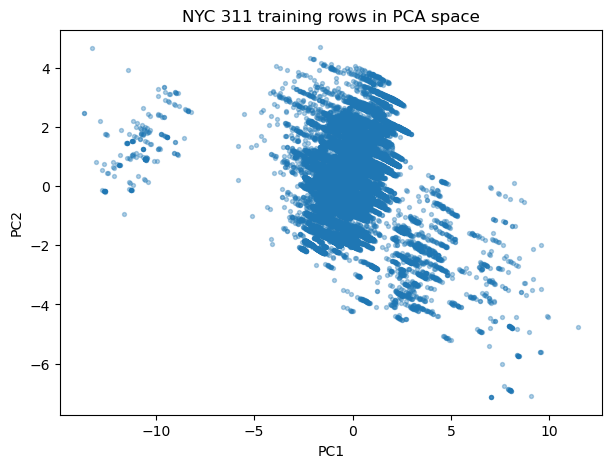

Explained variance by the 2D PCA view: 0.0983


In [69]:
pca2 = PCA(n_components=2, random_state=SEED)
Xtr_2d = pca2.fit_transform(Xtr_num)

plt.figure(figsize=(7, 5))
plt.scatter(Xtr_2d[:, 0], Xtr_2d[:, 1], s=8, alpha=0.35)
plt.title("NYC 311 training rows in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance by the 2D PCA view:", round(float(pca2.explained_variance_ratio_.sum()), 4))


## 6D.8 - Compare clustering methods with internal metrics

We now compare several clustering methods on the **same training representation**.

Important reminder:

- these metrics are **internal**
- they describe properties of the clustering
- they do **not** prove that the clustering is meaningful for the task

In [70]:
# Use a moderate subset so hierarchical clustering stays practical
cluster_n = min(6000, len(Xtr_num))
cluster_idx = rng.choice(len(Xtr_num), size=cluster_n, replace=False)

Xc = Xtr_num[cluster_idx]
yc = np.asarray(ytr)[cluster_idx]
Xc_2d = pca2.transform(Xc)

# k-means
km = KMeans(n_clusters=6, n_init=20, random_state=SEED)
km_labels = km.fit_predict(Xc)
km_sil = silhouette_score(Xc, km_labels)

# hierarchical
hc = AgglomerativeClustering(n_clusters=6, linkage="ward")
hc_labels = hc.fit_predict(Xc)
hc_sil = silhouette_score(Xc, hc_labels)

# DBSCAN
db = DBSCAN(eps=1.6, min_samples=20)
db_labels = db.fit_predict(Xc)
db_n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
db_noise_fraction = float(np.mean(db_labels == -1))

if db_n_clusters >= 2 and np.sum(db_labels != -1) > db_n_clusters:
    mask = db_labels != -1
    db_sil = silhouette_score(Xc[mask], db_labels[mask])
else:
    db_sil = float("nan")

summary = pd.DataFrame([
    {
        "method": "kmeans",
        "n_clusters": int(len(np.unique(km_labels))),
        "noise_fraction": 0.0,
        "silhouette": float(km_sil),
    },
    {
        "method": "hierarchical",
        "n_clusters": int(len(np.unique(hc_labels))),
        "noise_fraction": 0.0,
        "silhouette": float(hc_sil),
    },
    {
        "method": "dbscan",
        "n_clusters": int(db_n_clusters),
        "noise_fraction": float(db_noise_fraction),
        "silhouette_non_noise": float(db_sil) if np.isfinite(db_sil) else np.nan,
    },
])

display(summary)

,method,n_clusters,noise_fraction,silhouette,silhouette_non_noise
0,kmeans,6,0.000000,0.084955,NaN
1,hierarchical,6,0.000000,0.002094,NaN
2,dbscan,32,0.375833,NaN,0.412562


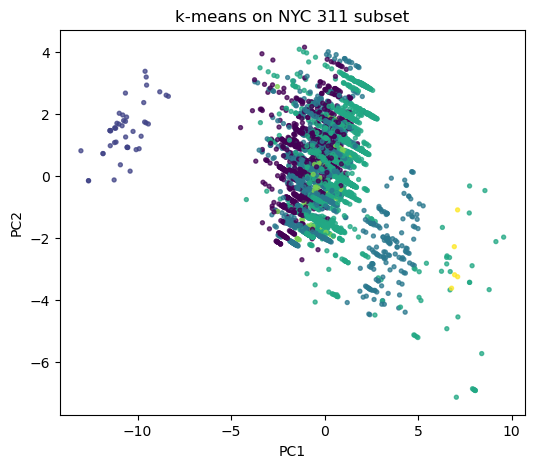

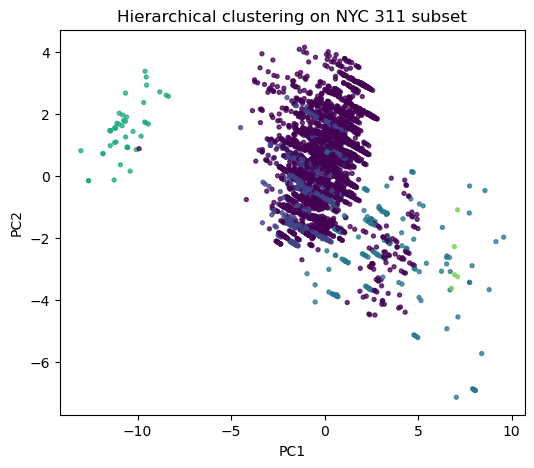

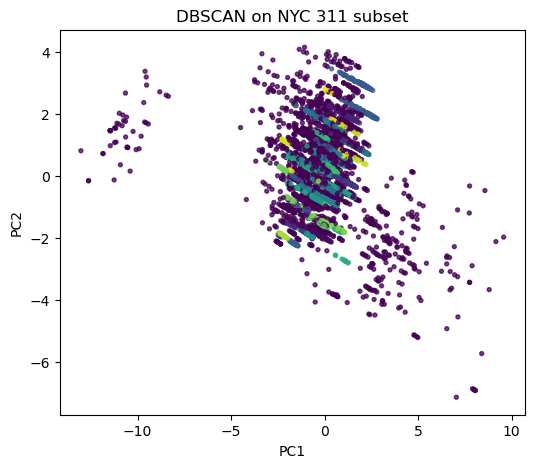

In [71]:
plt.figure(figsize=(6, 5))
plt.scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=km_labels, s=8, alpha=0.75)
plt.title("k-means on NYC 311 subset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=hc_labels, s=8, alpha=0.75)
plt.title("Hierarchical clustering on NYC 311 subset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=db_labels, s=8, alpha=0.75)
plt.title("DBSCAN on NYC 311 subset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 6D.9 - Domain-driven validation: do the clusters tell different stories?

Internal metrics are only part of the evaluation picture. Another useful question is:

**do the discovered groups differ in ways that humans can interpret?**

Here we profile each clustering against a few original columns from the same training subset.
We also look at `is_closed` as a teaching-only diagnostic.


In [72]:
Xtr_profile = Xtr.iloc[cluster_idx].copy()
Xtr_profile["y_true_is_closed"] = yc
Xtr_profile["kmeans_cluster"] = km_labels
Xtr_profile["hier_cluster"] = hc_labels
Xtr_profile["dbscan_cluster"] = db_labels

def cluster_profile(df_in, cluster_col, top_n=5):
    rows = []
    for lab, grp in df_in.groupby(cluster_col):
        rows.append({
            "cluster": lab,
            "n_rows": int(len(grp)),
            "closure_rate_teaching_only": float(grp["y_true_is_closed"].mean()),
            "top_agency": grp["agency"].mode().iloc[0] if "agency" in grp.columns and not grp["agency"].mode().empty else None,
            "top_borough": grp["borough_norm"].mode().iloc[0] if "borough_norm" in grp.columns and not grp["borough_norm"].mode().empty else None,
            "top_complaint": grp["complaint_topk"].mode().iloc[0] if "complaint_topk" in grp.columns and not grp["complaint_topk"].mode().empty else None,
        })
    out = pd.DataFrame(rows).sort_values("n_rows", ascending=False)
    return out.head(top_n)

print("k-means profiles")
display(cluster_profile(Xtr_profile, "kmeans_cluster"))

print("Hierarchical profiles")
display(cluster_profile(Xtr_profile, "hier_cluster"))

print("DBSCAN profiles")
display(cluster_profile(Xtr_profile, "dbscan_cluster"))


k-means profiles


,cluster,n_rows,closure_rate_teaching_only,top_agency,top_borough,top_complaint
3,3,2816,0.285156,DSNY,BROOKLYN,snow or ice
2,2,1962,0.370031,HPD,BRONX,heat/hot water
0,0,1071,0.633053,NYPD,BROOKLYN,other
4,4,99,0.030303,HPD,BRONX,door/window
1,1,46,0.413043,NYPD,QUEENS,noise - residential


Hierarchical profiles


,cluster,n_rows,closure_rate_teaching_only,top_agency,top_borough,top_complaint
0,0,4333,0.389568,DSNY,BROOKLYN,snow or ice
1,1,1446,0.302905,HPD,BRONX,heat/hot water
2,2,169,0.497041,DHS,MANHATTAN,homeless person assistance
3,3,45,0.422222,NYPD,QUEENS,noise - residential
4,4,6,0.333333,DOT,(missing),other


DBSCAN profiles


,cluster,n_rows,closure_rate_teaching_only,top_agency,top_borough,top_complaint
0,-1,2255,0.421729,HPD,BROOKLYN,other
14,13,343,0.198251,HPD,BRONX,heat/hot water
3,2,267,0.078652,DSNY,BROOKLYN,snow or ice
13,12,261,0.176245,HPD,BROOKLYN,heat/hot water
17,16,254,0.055118,DSNY,QUEENS,snow or ice


## 6D.10 - Stability and sensitivity checks

Section D emphasized that when full ground truth is absent, **stability itself becomes a form of evidence**.

We now check three kinds of sensitivity:

1. **k-means random initialization**
2. **k-means choice of k**
3. **DBSCAN choice of eps**

,seed,silhouette,ari_vs_seed0
0,0,0.056010,1.000000
1,1,0.085014,0.223195
2,2,0.261612,0.027701
3,3,0.017923,0.425753
4,4,0.084042,0.305332


,k,silhouette
0,4,0.066807
1,5,0.024028
2,6,0.084955
3,7,0.045735
4,8,0.088107


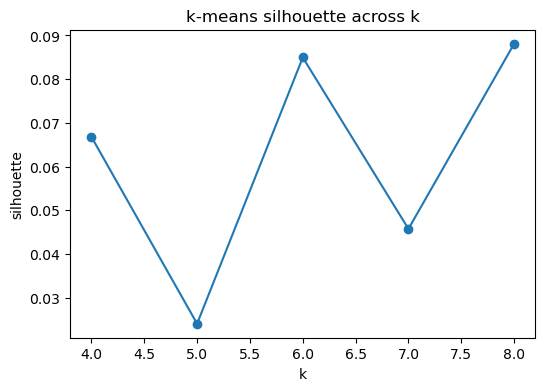

,eps,n_clusters,noise_fraction,silhouette_non_noise
0,1.2,39,0.431333,0.393486
1,1.4,40,0.412167,0.379246
2,1.6,32,0.375833,0.412562
3,1.8,26,0.324667,0.476697
4,2.0,37,0.267833,0.467977


In [74]:
# k-means stability across seeds
seed_rows = []
base_km = KMeans(n_clusters=6, n_init=1, random_state=0).fit_predict(Xc)

for seed in [0, 1, 2, 3, 4]:
    labels = KMeans(n_clusters=6, n_init=1, random_state=seed).fit_predict(Xc)
    seed_rows.append({
        "seed": seed,
        "silhouette": float(silhouette_score(Xc, labels)),
        "ari_vs_seed0": float(adjusted_rand_score(base_km, labels)),
    })

seed_df = pd.DataFrame(seed_rows)
display(seed_df)

# sensitivity to k
k_rows = []
for k in [4, 5, 6, 7, 8]:
    labels = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit_predict(Xc)
    k_rows.append({
        "k": k,
        "silhouette": float(silhouette_score(Xc, labels)),
    })

k_df = pd.DataFrame(k_rows)
display(k_df)

plt.figure(figsize=(6, 4))
plt.plot(k_df["k"], k_df["silhouette"], marker="o")
plt.title("k-means silhouette across k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()

# sensitivity to DBSCAN eps
db_rows = []
for eps in [1.2, 1.4, 1.6, 1.8, 2.0]:
    labels = DBSCAN(eps=eps, min_samples=20).fit_predict(Xc)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_fraction = float(np.mean(labels == -1))

    if n_clusters >= 2 and np.sum(labels != -1) > n_clusters:
        mask = labels != -1
        sil = float(silhouette_score(Xc[mask], labels[mask]))
    else:
        sil = np.nan

    db_rows.append({
        "eps": eps,
        "n_clusters": int(n_clusters),
        "noise_fraction": float(noise_fraction),
        "silhouette_non_noise": sil,
    })

db_df = pd.DataFrame(db_rows)
display(db_df)


## 6D.11 - Comparing algorithms with a small amount of label information

Section D also asked us to compare evaluation signals across method types.

We now recreate a semi-supervised setting similar to Module 6.C:

- most training labels are hidden
- only a small fraction remain visible
- we compare a visible-label-only supervised baseline against semi-supervised methods

This gives us one more kind of evaluation evidence.



In [75]:
visible_label_fraction = 0.10

visible_idx = []
for cls in np.unique(ytr):
    cls_idx = np.where(ytr == cls)[0]
    keep_n = max(1, int(round(len(cls_idx) * visible_label_fraction)))
    chosen = rng.choice(cls_idx, size=keep_n, replace=False)
    visible_idx.extend(chosen.tolist())

visible_idx = np.array(sorted(visible_idx))
label_mask = np.zeros(len(ytr), dtype=bool)
label_mask[visible_idx] = True

ytr_ssl = np.asarray(ytr).astype(int).copy()
ytr_ssl[~label_mask] = -1

print("Training rows:", len(ytr))
print("Visible labels:", int(label_mask.sum()))
print("Visible fraction:", round(float(label_mask.mean()), 4))
print("Unique values in ytr_ssl:", np.unique(ytr_ssl))

Training rows: 34999
Visible labels: 3499
Visible fraction: 0.1
Unique values in ytr_ssl: [-1  0  1]


In [76]:
# Supervised baseline using only visible labels
baseline_pipe = Pipeline([
    ("pre", build_preprocessor(Xtr)),
    ("logreg", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")),
])

baseline_pipe.fit(Xtr.iloc[label_mask], np.asarray(ytr)[label_mask])

p_va_base = baseline_pipe.predict_proba(Xva)[:, 1]
p_te_base = baseline_pipe.predict_proba(Xte)[:, 1]

baseline_val = eval_probs(yva, p_va_base, label="supervised_visible_only_val")
baseline_test = eval_probs(yte, p_te_base, label="supervised_visible_only_test")

display(pd.DataFrame([baseline_val, baseline_test]))

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,supervised_visible_only_val,0.5,0.862000,0.827210,0.802399,0.814616,0.923777,0.914911,0.098011,0.318730
1,supervised_visible_only_test,0.5,0.857352,0.813722,0.807407,0.810552,0.919067,0.911420,0.101011,0.328881


In [77]:
# Label spreading on a manageable subset of the numeric training representation
labelspread_n = min(8000, len(Xtr_num))
ls_idx = rng.choice(len(Xtr_num), size=labelspread_n, replace=False)

X_ls = sanitize_array(Xtr_num[ls_idx])
y_ls_true = np.asarray(ytr)[ls_idx].astype(int)
y_ls = np.asarray(ytr_ssl)[ls_idx].astype(int)

ls_model = LabelSpreading(kernel="knn", n_neighbors=15, alpha=0.2, max_iter=30)
ls_model.fit(X_ls, y_ls)

ls_subset_pred = ls_model.transduction_
ls_subset_acc = float((ls_subset_pred == y_ls_true).mean())
ls_unlabeled_acc = float((ls_subset_pred[y_ls == -1] == y_ls_true[y_ls == -1]).mean())

p_va_ls = ls_model.predict_proba(Xva_num)[:, 1]
p_te_ls = ls_model.predict_proba(Xte_num)[:, 1]

label_spreading_results = {
    "subset_accuracy_teaching_only": ls_subset_acc,
    "unlabeled_subset_accuracy_teaching_only": ls_unlabeled_acc,
    "n_subset": int(len(y_ls_true)),
    "n_labeled": int(np.sum(y_ls != -1)),
    "n_unlabeled": int(np.sum(y_ls == -1)),
}

display(pd.DataFrame([
    eval_probs(yva, p_va_ls, label="label_spreading_val"),
    eval_probs(yte, p_te_ls, label="label_spreading_test"),
]))
print(label_spreading_results)

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,label_spreading_val,0.5,0.819600,0.759733,0.764291,0.762005,0.883712,0.857268,0.139763,0.841436
1,label_spreading_test,0.5,0.819757,0.757734,0.768959,0.763305,0.884578,0.859022,0.137738,0.825503


{'subset_accuracy_teaching_only': 0.83825, 'unlabeled_subset_accuracy_teaching_only': 0.8204024982650937, 'n_subset': 8000, 'n_labeled': 795, 'n_unlabeled': 7205}


In [79]:
# Self-training / pseudo-labeling
base_estimator = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",
)

try:
    self_training_model = SelfTrainingClassifier(
        estimator=base_estimator,
        threshold=0.85,
        max_iter=10,
        verbose=True,
    )
except TypeError:
    self_training_model = SelfTrainingClassifier(
        base_estimator=base_estimator,
        threshold=0.85,
        max_iter=10,
        verbose=True,
    )

self_training_model.fit(Xtr_num, ytr_ssl)

p_va_st = self_training_model.predict_proba(Xva_num)[:, 1]
p_te_st = self_training_model.predict_proba(Xte_num)[:, 1]

pseudo_val = eval_probs(yva, p_va_st, label="pseudo_labeling_val")
pseudo_test = eval_probs(yte, p_te_st, label="pseudo_labeling_test")

display(pd.DataFrame([pseudo_val, pseudo_test]))

End of iteration 1, added 19162 new labels.
End of iteration 2, added 4593 new labels.
End of iteration 3, added 1168 new labels.
End of iteration 4, added 509 new labels.
End of iteration 5, added 372 new labels.
End of iteration 6, added 408 new labels.
End of iteration 7, added 398 new labels.
End of iteration 8, added 436 new labels.
End of iteration 9, added 411 new labels.
End of iteration 10, added 291 new labels.


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,pseudo_labeling_val,0.5,0.85760,0.802812,0.826041,0.814261,0.920336,0.910832,0.115492,0.499965
1,pseudo_labeling_test,0.5,0.85242,0.787234,0.835273,0.810543,0.916446,0.908320,0.119999,0.522303


## 6D.12 - Put the evidence together

At this point we have several kinds of evaluation signals:

- **internal metrics** for clustering
- **stability checks** under different choices
- **domain-driven cluster profiles**
- **semi-supervised predictive performance** with sparse labels

No single signal is enough by itself. The point of this notebook is to compare them side by side.


In [81]:
comparison = pd.DataFrame([
    baseline_val,
    baseline_test,
    eval_probs(yva, p_va_ls, label="label_spreading_val"),
    eval_probs(yte, p_te_ls, label="label_spreading_test"),
    pseudo_val,
    pseudo_test,
])

display(comparison)

print("Clustering summary:")
display(summary)

print("k-means seed stability:")
display(seed_df)

print("DBSCAN eps sensitivity:")
display(db_df)


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss
0,supervised_visible_only_val,0.5,0.862000,0.827210,0.802399,0.814616,0.923777,0.914911,0.098011,0.318730
1,supervised_visible_only_test,0.5,0.857352,0.813722,0.807407,0.810552,0.919067,0.911420,0.101011,0.328881
2,label_spreading_val,0.5,0.819600,0.759733,0.764291,0.762005,0.883712,0.857268,0.139763,0.841436
3,label_spreading_test,0.5,0.819757,0.757734,0.768959,0.763305,0.884578,0.859022,0.137738,0.825503
4,pseudo_labeling_val,0.5,0.857600,0.802812,0.826041,0.814261,0.920336,0.910832,0.115492,0.499965
5,pseudo_labeling_test,0.5,0.852420,0.787234,0.835273,0.810543,0.916446,0.908320,0.119999,0.522303


Clustering summary:


,method,n_clusters,noise_fraction,silhouette,silhouette_non_noise
0,kmeans,6,0.000000,0.084955,NaN
1,hierarchical,6,0.000000,0.002094,NaN
2,dbscan,32,0.375833,NaN,0.412562


k-means seed stability:


,seed,silhouette,ari_vs_seed0
0,0,0.056010,1.000000
1,1,0.085014,0.223195
2,2,0.261612,0.027701
3,3,0.017923,0.425753
4,4,0.084042,0.305332


DBSCAN eps sensitivity:


,eps,n_clusters,noise_fraction,silhouette_non_noise
0,1.2,39,0.431333,0.393486
1,1.4,40,0.412167,0.379246
2,1.6,32,0.375833,0.412562
3,1.8,26,0.324667,0.476697
4,2.0,37,0.267833,0.467977


## 13) What happened?

Use the outputs above to answer:

1. Which clustering method looked strongest by **internal metrics**?
2. Which method looked strongest by **interpretability**?
3. Were the clustering results **stable** under reasonable changes?
4. Did semi-supervised learning improve over the visible-label-only baseline?
5. Did all evaluation signals point in the same direction, or did they disagree?

A few reminders:

- if metrics disagree, that is not a mistake — it is part of the lesson
- if a clustering has a good internal score but weak domain interpretation, be cautious
- if a method is unstable, that instability is itself evidence
- if semi-supervised methods help, that suggests the unlabeled structure contains useful information

The main lesson of Module 6.D is:

**evaluation in unsupervised and semi-supervised learning is about combining evidence, not trusting a single number.**
